# Cost-Axis Risk Curves

Interactive version of `plot_cost_curves.py` — loads cost metrics CSVs, aggregates
across seeds, and renders comparison / per-model / per-category figures inline.

**Typical workflow:**
1. Edit the **Configuration** cell to point at your CSVs.
2. Run all cells (`Kernel → Restart & Run All`).
3. Tweak any plot cell and re-run just that cell.

## Configuration
Edit this cell to change which data is loaded and how plots are styled.

In [35]:
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
PLOTS_BASE = Path(
    "/Users/malikehehghaghi/Downloads/prisk-pressure/"
    "results/plots/multitrial_experiments/pressure_sensitivity"
)
OUTPUT_DIR = Path(
    "/Users/malikehehghaghi/Downloads/prisk-pressure/"
    "results/plots/cost/harmbench/ablations/qwen_size/flops"
)

# Cost metrics CSVs (one per model / seed-group)
COST_CSVS = [
    PLOTS_BASE / "harmbench/qwen2.5-0.5b-instruct/cost/cost_metrics.csv",
    PLOTS_BASE / "harmbench/qwen2.5-3b-instruct/cost/cost_metrics.csv",
    PLOTS_BASE / "harmbench/qwen2.5-7b-instruct/cost/cost_metrics.csv",
]

# Per-category CSVs (same order as COST_CSVS; leave empty list to skip)
CATEGORY_CSVS = [
    PLOTS_BASE / "harmbench/qwen2.5-0.5b-instruct/cost/cost_metrics_by_category.csv",
    PLOTS_BASE / "harmbench/qwen2.5-3b-instruct/cost/cost_metrics_by_category.csv",
    PLOTS_BASE / "harmbench/qwen2.5-7b-instruct/cost/cost_metrics_by_category.csv",
]

# ── Plot options ───────────────────────────────────────────────────────────────
X_AXIS   = "flops"           # "tokens" or "flops"
TITLE    = "HarmBench — Model Size Effect on Adversarial Compute Cost"  # suptitle for comparison figures
MODE     = "comparison"       # "all" | "per-seed" | "aggregated" | "comparison"
FMT      = "png"              # "png" | "pdf" | "svg"
SKIP_MISSING = True

# Restrict to specific attacks (None = all)
FILTER_ATTACKS = None         # e.g. ["gcg", "pair"]

# ── Save toggles ──────────────────────────────────────────────────────────────
SAVE_FIGURES = True           # set True to write PNGs to OUTPUT_DIR
DPI          = 150


## Imports & Style

In [36]:
import re
import sys

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats as scipy_stats

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Allow importing from the project root
PROJECT_ROOT = Path("../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import data utilities directly from the script
from plot_cost_curves import (
    aggregate_seeds,
    aggregate_seeds_by_category,
    load_category_cost_csv,
    load_cost_csv,
    _setup_style,
    _xcol,
    _style_axes,
    _attack_label,
    _model_label,
    _category_label,
    _model_color,
    _category_color,
    _reformat_title,
    _base,
    ATTACK_MARKERS,
    ATTACK_LINESTYLES,
    MODEL_COLORS,
    MODEL_LINESTYLES_LIST,
    PALETTE,
    _CATEGORY_PALETTE,
)

_setup_style()

sns.set_style("white")
sns.set_style("ticks")
sns.set_context("notebook", font_scale=1.3)

!wget https://github.com/googlefonts/atkinson-hyperlegible/raw/refs/heads/main/fonts/ttf/AtkinsonHyperlegible-Regular.ttf
matplotlib.font_manager.fontManager.addfont('AtkinsonHyperlegible-Regular.ttf')
plt.rcParams.update({"font.family": "Atkinson Hyperlegible"})

print(f"matplotlib {matplotlib.__version__}, seaborn {sns.__version__}")

--2026-06-11 23:07:46--  https://github.com/googlefonts/atkinson-hyperlegible/raw/refs/heads/main/fonts/ttf/AtkinsonHyperlegible-Regular.ttf
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/googlefonts/atkinson-hyperlegible/refs/heads/main/fonts/ttf/AtkinsonHyperlegible-Regular.ttf [following]
--2026-06-11 23:07:46--  https://raw.githubusercontent.com/googlefonts/atkinson-hyperlegible/refs/heads/main/fonts/ttf/AtkinsonHyperlegible-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54348 (53K) [application/octet-stream]
Saving to: ‘AtkinsonHyperlegible-Regular.ttf.177’

AtkinsonHyperlegib

In [37]:
# Qwen purple palette — light → dark maps to small → large model
# Base hue from Qwen's violet-purple brand identity
QWEN_PURPLES = [
    "#C4B5FD",  # lightest  (smallest model)
    "#7C3AED",  # mid
    "#3B0764",  # darkest   (largest model)
]

def qwen_color_map(models: list) -> dict:
    """Assign Qwen purple shades ordered small → large (alphabetical sort works for Qwen sizes)."""
    ordered = sorted(models)
    n = len(ordered)
    if n == 1:
        indices = [1]
    else:
        indices = [round(i * (len(QWEN_PURPLES) - 1) / (n - 1)) for i in range(n)]
    return {m: QWEN_PURPLES[idx] for m, idx in zip(ordered, indices)}

## Load & Prepare Data

In [38]:
COST_CSVS

[PosixPath('/Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/multitrial_experiments/pressure_sensitivity/harmbench/qwen2.5-0.5b-instruct/cost/cost_metrics.csv'),
 PosixPath('/Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/multitrial_experiments/pressure_sensitivity/harmbench/qwen2.5-3b-instruct/cost/cost_metrics.csv'),
 PosixPath('/Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/multitrial_experiments/pressure_sensitivity/harmbench/qwen2.5-7b-instruct/cost/cost_metrics.csv')]

In [39]:
df_raw = load_cost_csv(COST_CSVS, skip_missing=SKIP_MISSING)

# Drop legacy attack variant
df_raw = df_raw[df_raw["attack_id"] != "jailbroken-v1"]

if FILTER_ATTACKS:
    df_raw = df_raw[df_raw["attack_id"].isin(FILTER_ATTACKS)]

xcol = _xcol(X_AXIS)
assert xcol in df_raw.columns, (
    f"Column '{xcol}' not found — run scripts/compute_attack_costs.py first."
)

df_agg = aggregate_seeds(df_raw)

n_base = df_raw["model_id"].apply(_base).nunique()
print(
    f"Loaded {len(df_raw):,} rows — {n_base} base model(s), "
    f"{df_raw['attack_id'].nunique()} attack(s)  [x-axis: {X_AXIS}]"
)
df_agg[["model_id", "attack_id", "lambda", "risk", "risk_lower", "risk_upper", "n_seeds"]].head()

Loaded 623 rows — 3 base model(s), 3 attack(s)  [x-axis: flops]


,model_id,attack_id,lambda,risk,risk_lower,risk_upper,n_seeds
0,qwen2.5-0.5b-instruct,gcg,0,0.0000,0.000000,0.000000,10
1,qwen2.5-0.5b-instruct,gcg,1,0.3425,0.327680,0.357320,10
2,qwen2.5-0.5b-instruct,gcg,2,0.5070,0.481529,0.532471,10
3,qwen2.5-0.5b-instruct,gcg,4,0.7425,0.726932,0.758068,10
4,qwen2.5-0.5b-instruct,gcg,6,0.8940,0.887089,0.900911,10


In [40]:
# Load per-category data (optional)
df_cat_raw = pd.DataFrame()
df_cat_agg = pd.DataFrame()

if CATEGORY_CSVS:
    df_cat_raw = load_category_cost_csv(CATEGORY_CSVS, skip_missing=SKIP_MISSING)
    if not df_cat_raw.empty:
        df_cat_raw = df_cat_raw[df_cat_raw["attack_id"] != "jailbroken-v1"]
        if FILTER_ATTACKS:
            df_cat_raw = df_cat_raw[df_cat_raw["attack_id"].isin(FILTER_ATTACKS)]
        df_cat_agg = aggregate_seeds_by_category(df_cat_raw)
        print(f"Category data: {len(df_cat_agg):,} rows, "
              f"{df_cat_agg['category'].nunique()} categories")
    else:
        print("No category data found (skipped).")
else:
    print("CATEGORY_CSVS is empty — skipping category plots.")

Category data: 378 rows, 6 categories


## Comparison Plots
One figure per attack — all (seed-aggregated) models overlaid with inline labels.
Mirrors `plot_comparison()` + `plot_combined()` from the script.

  Saved: /Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/cost/harmbench/ablations/qwen_size/flops/cost_comparison_all.png


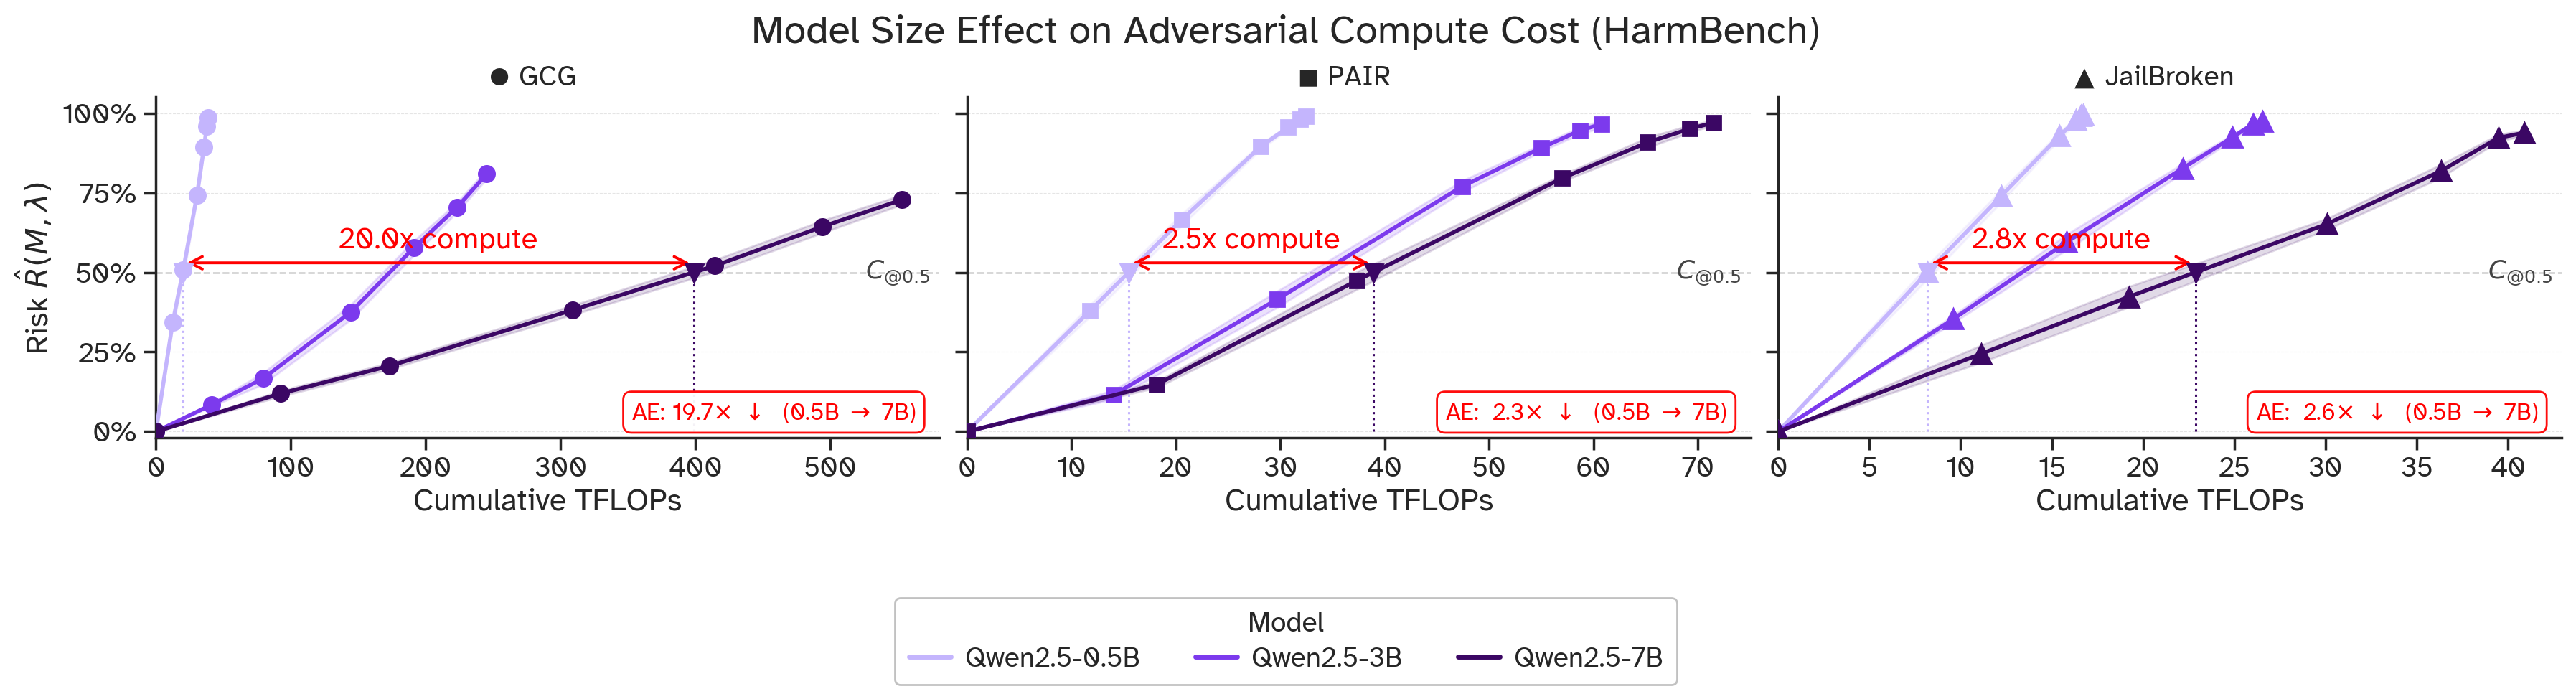

In [41]:
def _save(fig, path: Path, extra_artists=()) -> None:
    if SAVE_FIGURES:
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, dpi=DPI, bbox_inches="tight",
                    bbox_extra_artists=extra_artists, pad_inches=0.1)
        print(f"  Saved: {path}")


def _interp_c_at_risk(df_m: pd.DataFrame, col: str, target: float = 0.5):
    """Linearly interpolate x where risk first crosses `target`."""
    df_s = df_m.sort_values(col)
    r, x = df_s["risk"].values, df_s[col].values
    for i in range(len(r) - 1):
        if r[i] <= target <= r[i + 1] and r[i + 1] > r[i]:
            t = (target - r[i]) / (r[i + 1] - r[i])
            return float(x[i] + t * (x[i + 1] - x[i]))
    return None


_ATTACK_TITLES = {
    "gcg":        "GCG",
    "pair":       "PAIR",
    "jailbroken": "JailBroken",
}

_AE_LABELS = {
    "gcg":        r"AE: 19.7$\times$ $\downarrow$  (0.5B $\to$ 7B)",
    "pair":       r"AE:  2.3$\times$ $\downarrow$  (0.5B $\to$ 7B)",
    "jailbroken": r"AE:  2.6$\times$ $\downarrow$  (0.5B $\to$ 7B)",
}

_ANNOT_COLOR = "red"
_ATTACK_ORDER = {"gcg": 0, "pair": 1, "jailbroken": 2}

_ATTACK_MARKERS = {"gcg": "o", "pair": "s", "jailbroken": "^"}
_MARKER_SIZES   = {"o": 8, "s": 7, "^": 10}

# Mathtext glyphs rendered by STIX fonts — independent of Atkinson Hyperlegible
_MARKER_GLYPH = {"o": r"$\bullet$", "s": r"$\blacksquare$", "^": r"$\blacktriangle$"}

# Per-glyph fontsize to equalize apparent visual weight across shapes
_GLYPH_FS = {"o": 30, "s": 11, "^": 20}


def _annotate_c_at_risk(ax, df_a, ordered_models, col, color_map, attack, target=0.5):
    """Default: C@0.5 arrow spanning the two endpoint models in ordered_models."""
    small_m, large_m = ordered_models[0], ordered_models[-1]
    c_small = _interp_c_at_risk(df_a[df_a["model_id"] == small_m], col, target)
    c_large = _interp_c_at_risk(df_a[df_a["model_id"] == large_m], col, target)

    ax.axhline(target, color="#cccccc", linewidth=0.9, linestyle="--", zorder=1)
    ax.text(
        0.988, target, r"$C_{@0.5}$",
        transform=ax.get_yaxis_transform(),
        va="center", ha="right", fontsize=13, color="#444444", fontweight="bold",
    )

    for c, m in [(c_small, small_m), (c_large, large_m)]:
        if c is None:
            continue
        color = color_map[m]
        ax.vlines(c, 0, target, color=color, linewidth=1.1, linestyle=":", zorder=2)
        ax.plot(c, target, marker="v", color=color, markersize=9, zorder=6, clip_on=False)

    if c_small is not None and c_large is not None and c_small > 0:
        ratio  = c_large / c_small
        is_log = ax.get_xscale() == "log"
        x_mid  = (
            np.exp((np.log(c_small) + np.log(c_large)) / 2) if is_log
            else (c_small + c_large) / 2
        )
        arrow_y = target + 0.03
        ax.annotate(
            "", xy=(c_large, arrow_y), xytext=(c_small, arrow_y),
            arrowprops=dict(arrowstyle="<->", color=_ANNOT_COLOR, lw=1.4),
            annotation_clip=False,
        )
        ax.text(
            x_mid, arrow_y + 0.03, f"{ratio:.1f}x compute",
            ha="center", va="bottom", fontsize=15,
            fontweight="bold", color=_ANNOT_COLOR,
        )

    if attack in _AE_LABELS:
        ax.text(
            0.97, 0.04, _AE_LABELS[attack],
            transform=ax.transAxes,
            ha="right", va="bottom", fontsize=12, color=_ANNOT_COLOR,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                      edgecolor=_ANNOT_COLOR, alpha=0.95),
        )


def show_comparison(
    df_agg: pd.DataFrame,
    x_axis: str = X_AXIS,
    suptitle: str = TITLE,
    color_map_fn=None,
    model_order: dict = None,
    annotate_fn=None,
) -> None:
    if color_map_fn is None:
        color_map_fn = qwen_color_map
    if annotate_fn is None:
        annotate_fn = _annotate_c_at_risk

    col       = _xcol(x_axis)
    models    = sorted(df_agg["model_id"].unique())
    attacks   = sorted(df_agg["attack_id"].unique(),
                       key=lambda a: _ATTACK_ORDER.get(a, 99))
    color_map = color_map_fn(models)
    # ordered controls both the C@0.5 arrow endpoints and the legend order
    ordered   = (
        sorted(models, key=lambda m: model_order.get(m, 99))
        if model_order else sorted(models)
    )

    n_attacks = len(attacks)
    fig, axes = plt.subplots(1, n_attacks, figsize=(6 * n_attacks, 4.5), sharey=True)
    if n_attacks == 1:
        axes = [axes]

    # ── Pass 1: curves + titles (name only, glyph added later) ────────────────
    attack_marker_map = {}
    for ax, attack in zip(axes, attacks):
        df_a   = df_agg[df_agg["attack_id"] == attack]
        x_max  = float(df_a[col].max()) if not df_a.empty else 1.0
        marker = _ATTACK_MARKERS.get(attack, "o")
        msize  = _MARKER_SIZES.get(marker, 8)
        attack_marker_map[attack] = marker

        for model in models:
            df_m = df_a[df_a["model_id"] == model].sort_values(col)
            if df_m.empty:
                continue
            color = color_map[model]
            ax.plot(
                df_m[col], df_m["risk"],
                color=color, label=_model_label(model),
                marker=marker, linestyle="-", linewidth=2.0, markersize=msize, zorder=3,
            )
            if "n_seeds" in df_m.columns and (df_m["n_seeds"] > 1).any():
                ax.fill_between(
                    df_m[col], df_m["risk_lower"], df_m["risk_upper"],
                    color=color, alpha=0.15, zorder=2,
                )

        base_title = _ATTACK_TITLES.get(attack, _attack_label(attack))
        _style_axes(ax, base_title, x_max, x_axis)
        ax.title.set_fontsize(14)
        ax.title.set_fontweight("bold")
        annotate_fn(ax, df_a, ordered, col, color_map, attack)

    for ax in axes[1:]:
        ax.set_ylabel("")

    # ── Legend (ordered) + suptitle ───────────────────────────────────────────
    legend_handles = [
        Line2D([0], [0], color=color_map[m], linewidth=2.5)
        for m in ordered
    ]
    legend_labels = [_model_label(m) for m in ordered]
    leg = fig.legend(
        legend_handles, legend_labels,
        title="Model", loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncols=len(models),
        fontsize=14, title_fontsize=14,
        frameon=True, facecolor="white", edgecolor="#bbbbbb", framealpha=0.9,
        borderpad=0.5, labelspacing=0.4, handlelength=1.5, handletextpad=0.5,
    )
    sup = None
    if suptitle:
        sup = fig.suptitle(_reformat_title(suptitle), fontsize=20, fontweight="bold")

    # ── tight_layout first, then measure, then place glyphs via fig.text ──────
    fig.tight_layout(pad=0.5, rect=[0, 0.18, 1, 1])
    fig.canvas.draw()

    renderer    = fig.canvas.get_renderer()
    disp_to_fig = fig.transFigure.inverted()
    gap_px      = 5 * fig.dpi / 72

    for ax, attack in zip(axes, attacks):
        marker = attack_marker_map[attack]
        glyph  = _MARKER_GLYPH.get(marker, "")
        if not glyph:
            continue
        title_bbox = ax.title.get_window_extent(renderer=renderer)
        gx, gy = disp_to_fig.transform(
            (title_bbox.x0 - gap_px,
             (title_bbox.y0 + title_bbox.y1) / 2)
        )
        fig.text(gx, gy, glyph,
                 fontsize=_GLYPH_FS.get(marker, 15), fontweight="bold",
                 ha="right", va="center")

    extra = [leg] + ([sup] if sup is not None else [])
    _save(fig, OUTPUT_DIR / f"cost_comparison_all.{FMT}", extra_artists=extra)
    plt.show()


if MODE in ("all", "comparison") and n_base > 1:
    show_comparison(df_agg)


## Model Size Effect — GCG vs JailBroken (Side-by-Side)
Left: GCG — scale provides strong protection (C@0.5 grows 20x, ASR drops 99%→73%).
Right: JailBroken — scale barely helps (C@0.5 grows only 2.8x, ASR barely drops 99%→94%).
AE annotation removed; annotations show C@0.5 multiplier and ASR drop to highlight the contrast.

  Saved: /Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/cost/harmbench/ablations/qwen_size/flops/cost_comparison_gcg_jailbroken.png


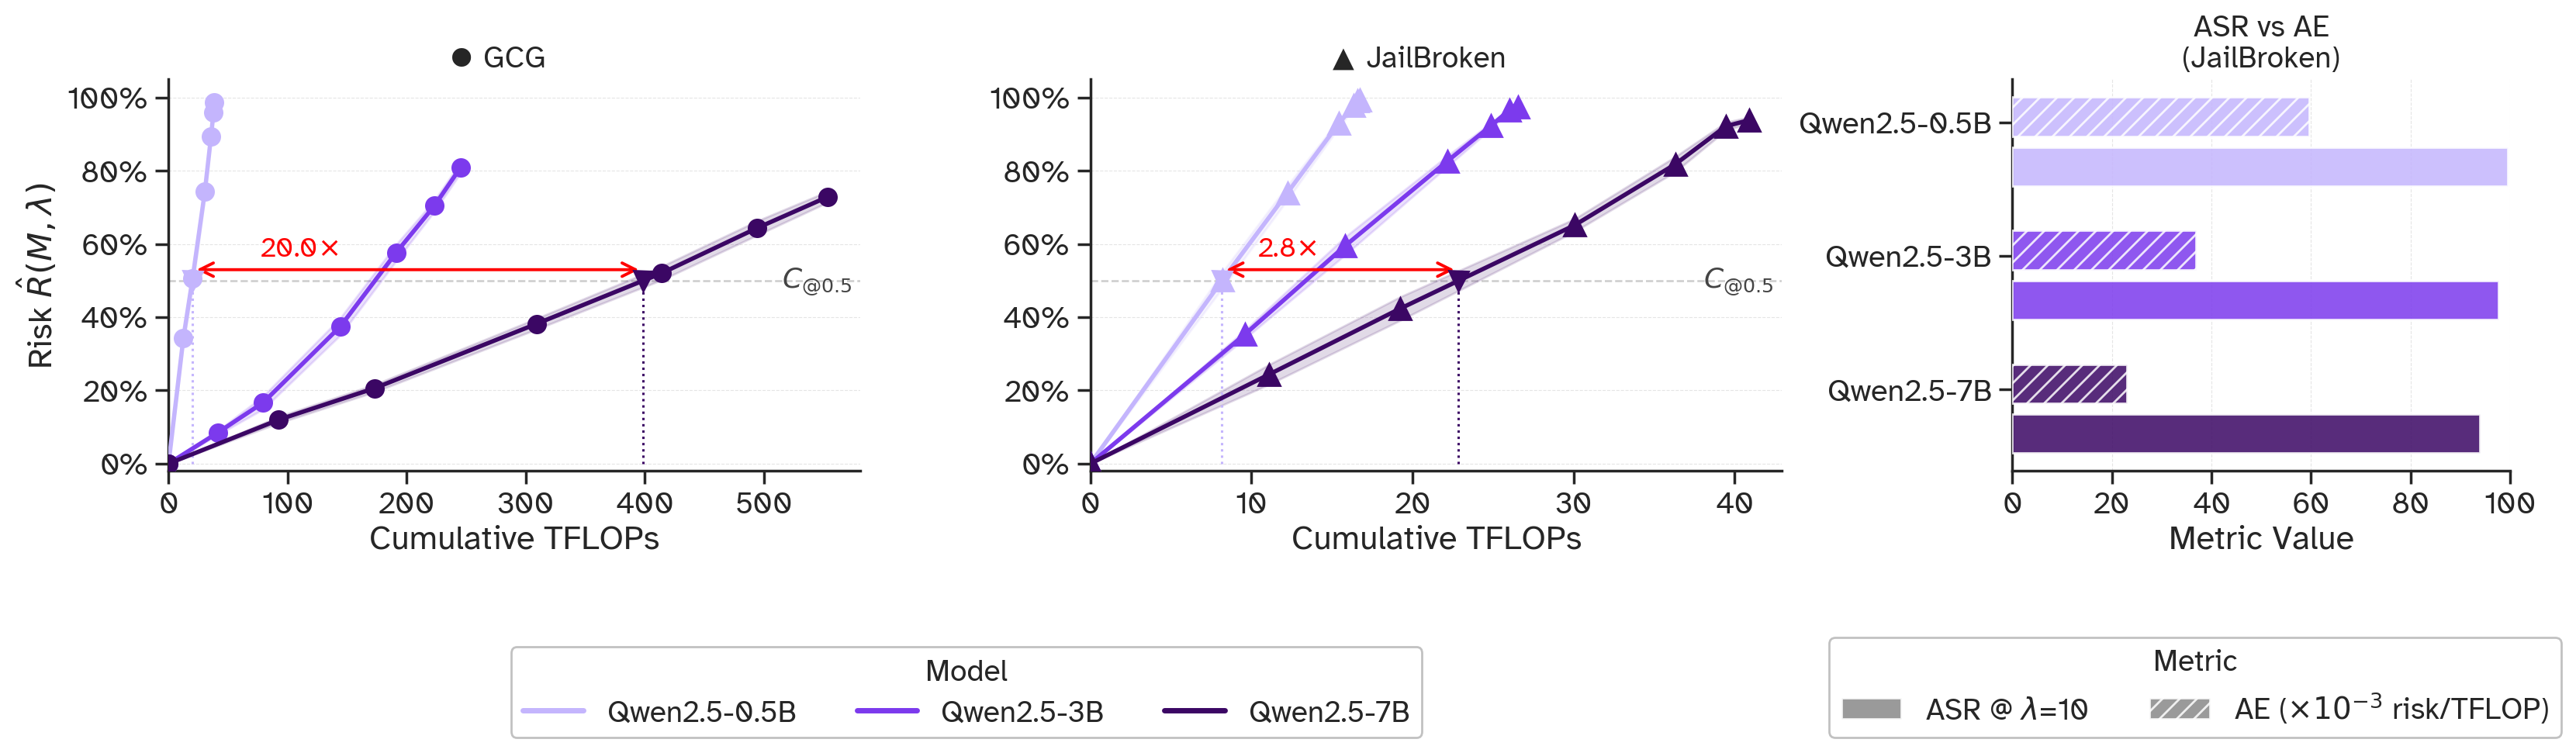

In [42]:
# ── Model size effect: GCG vs JailBroken side-by-side ───────────────────────
# Filters df_agg to the two attacks, creates a two-panel figure,
# and annotates each panel with C@0.5 multiplier and ASR-at-lambda-10 drop.

_attacks_sz = ['gcg', 'jailbroken']
_df_sz      = df_agg[df_agg['attack_id'].isin(_attacks_sz)]
_col_sz     = _xcol(X_AXIS)

_ordered_sz = sorted(_df_sz['model_id'].unique())   # 0.5B, 3B, 7B
_cmap_sz    = qwen_color_map(_ordered_sz)
_small_m    = _ordered_sz[0]   # Qwen2.5-0.5B
_large_m    = _ordered_sz[-1]  # Qwen2.5-7B

_n_atk      = len(_attacks_sz)
fig_sz = plt.figure(figsize=(6 * _n_atk + 4.5, 4.5))
_gs    = fig_sz.add_gridspec(1, _n_atk + 1, width_ratios=[1] * _n_atk + [0.72])
axes_sz = [fig_sz.add_subplot(_gs[0, i]) for i in range(_n_atk)]
ax_bar  = fig_sz.add_subplot(_gs[0, _n_atk])
axes_sz[1].sharey(axes_sz[0])

for ax, attack in zip(axes_sz, _attacks_sz):
    df_a   = _df_sz[_df_sz['attack_id'] == attack]
    x_max  = float(df_a[_col_sz].max())
    marker = _ATTACK_MARKERS.get(attack, 'o')
    msize  = _MARKER_SIZES.get(marker, 8)

    # ── Risk curves ───────────────────────────────────────────────────────
    for model in _ordered_sz:
        df_m = df_a[df_a['model_id'] == model].sort_values(_col_sz)
        if df_m.empty:
            continue
        ax.plot(df_m[_col_sz], df_m['risk'],
                color=_cmap_sz[model], marker=marker,
                linestyle='-', linewidth=2.0, markersize=msize, zorder=3)
        if 'n_seeds' in df_m.columns and (df_m['n_seeds'] > 1).any():
            ax.fill_between(df_m[_col_sz], df_m['risk_lower'], df_m['risk_upper'],
                            color=_cmap_sz[model], alpha=0.15, zorder=2)

    # ── C@0.5 dashed line ─────────────────────────────────────────────────
    ax.axhline(0.5, color='#cccccc', linewidth=0.9, linestyle='--', zorder=1)
    ax.text(0.988, 0.5, r"$C_{@0.5}$",
            transform=ax.get_yaxis_transform(),
            va='center', ha='right', fontsize=13, color='#444444', fontweight='bold')

    # ── Vlines + markers for 0.5B and 7B at C@0.5 ────────────────────────
    c_small = _interp_c_at_risk(df_a[df_a['model_id'] == _small_m], _col_sz, 0.5)
    c_large = _interp_c_at_risk(df_a[df_a['model_id'] == _large_m], _col_sz, 0.5)
    for c, m in [(c_small, _small_m), (c_large, _large_m)]:
        if c is None:
            continue
        ax.vlines(c, 0, 0.5, color=_cmap_sz[m], linewidth=1.1, linestyle=':', zorder=2)
        ax.plot(c, 0.5, marker='v', color=_cmap_sz[m], markersize=9, zorder=6, clip_on=False)

    # ── C@0.5 multiplier arrow ────────────────────────────────────────────
    if c_small is not None and c_large is not None and c_small > 0:
        ratio   = c_large / c_small
        x_mid   = (c_small + c_large) / 2
        arrow_y = 0.53
        ax.annotate('', xy=(c_large, arrow_y), xytext=(c_small, arrow_y),
                    arrowprops=dict(arrowstyle='<->', color=_ANNOT_COLOR, lw=1.4),
                    annotation_clip=False)
        ax.text(c_small + (c_large - c_small) * 0.15, arrow_y + 0.025,
                f"{ratio:.1f}$\\times$",
                ha='left', va='bottom', fontsize=13,
                fontweight='bold', color=_ANNOT_COLOR)

    # # ── ASR at lambda=10 annotation (0.5B vs 7B) ─────────────────────────
    # lam_max = df_a['lambda'].max()
    # asr_s = df_a[(df_a['model_id'] == _small_m) & (df_a['lambda'] == lam_max)]['risk']
    # asr_l = df_a[(df_a['model_id'] == _large_m) & (df_a['lambda'] == lam_max)]['risk']
    # if not asr_s.empty and not asr_l.empty:
    #     ax.text(0.97, 0.05, f"ASR@$\\lambda$=10:  {float(asr_s.iloc[0]):.0%} $\\to$ {float(asr_l.iloc[0]):.0%}",
    #             transform=ax.transAxes, ha='right', va='bottom',
    #             fontsize=12, color=_ANNOT_COLOR, fontweight='bold',
    #             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
    #                       edgecolor=_ANNOT_COLOR, linewidth=1.2, alpha=0.95))

    _style_axes(ax, _ATTACK_TITLES.get(attack, _attack_label(attack)), x_max, X_AXIS)
    ax.title.set_fontsize(14)
    ax.title.set_fontweight('bold')

axes_sz[1].set_ylabel('')

# ── Right panel: ASR vs AE per model size (JailBroken) ───────────────────
# AE values hard-coded from Table 1 ($\times10^{-3}$ risk/TFLOP); ASR scaled to 0-100
_lam_bar = _df_sz['lambda'].max()
_atk_bar = 'jailbroken'

_AE_HB_JB = {
    'qwen2.5-0.5b-instruct': 59.6,
    'qwen2.5-3b-instruct':   36.8,
    'qwen2.5-7b-instruct':   23.0,
}

_bh   = 0.28
_bgap = 0.08
_ggap = 0.32

_yticks, _ylabels = [], []
_y = 0.0
for _model in _ordered_sz[::-1]:   # 7B at top
    _color = _cmap_sz[_model]
    _df_pt = _df_sz[(_df_sz['model_id'] == _model) & (_df_sz['attack_id'] == _atk_bar)
                     & (_df_sz['lambda'] == _lam_bar)]
    _asr = float(_df_pt['risk'].iloc[0]) * 100 if not _df_pt.empty else 0.0
    _ae  = _AE_HB_JB.get(_model, 0.0)
    ax_bar.barh(_y,              _asr, height=_bh, color=_color, alpha=0.85, zorder=3)
    ax_bar.barh(_y + _bh + _bgap, _ae,  height=_bh, color=_color, alpha=0.85,
                hatch='///', edgecolor='white', zorder=3)
    _yticks.append(_y + _bh + _bgap / 2)
    _ylabels.append(_model_label(_model))
    _y += 2 * _bh + _bgap + _ggap

ax_bar.set_yticks(_yticks)
ax_bar.set_yticklabels(_ylabels)
ax_bar.set_xlim(0, 100)
ax_bar.xaxis.set_major_locator(mticker.MultipleLocator(20))
ax_bar.set_xlabel(r'Metric Value')
ax_bar.set_title('ASR vs AE\n(JailBroken)', fontsize=14, fontweight='bold')
sns.despine(ax=ax_bar)
ax_bar.grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.5)
ax_bar.tick_params(direction='out')

# Legend
legend_handles_sz = [
    Line2D([0], [0], color=_cmap_sz[m], linewidth=2.5, label=_model_label(m))
    for m in _ordered_sz
]
leg_sz = fig_sz.legend(
    legend_handles_sz, [_model_label(m) for m in _ordered_sz],
    title='Model', loc='lower center', bbox_to_anchor=(0.38, -0.08),
    ncols=len(_ordered_sz), fontsize=14, title_fontsize=14,
    frameon=True, facecolor='white', edgecolor='#bbbbbb', framealpha=0.9,
)
from matplotlib.patches import Patch as _Patch
leg_bar = fig_sz.legend(
    handles=[
        _Patch(facecolor='#888888', alpha=0.85, label=r'ASR @ $\lambda$=' + str(int(_lam_bar))),
        _Patch(facecolor='#888888', alpha=0.85, hatch='///', edgecolor='white',
               label=r'AE ($\times10^{-3}$ risk/TFLOP)'),
    ],
    title='Metric', loc='lower center', bbox_to_anchor=(0.86, -0.08),
    ncols=2, fontsize=14, title_fontsize=14,
    frameon=True, facecolor='white', edgecolor='#bbbbbb', framealpha=0.9,
)
# sup_sz = fig_sz.suptitle(
#     'Model Size Effect — GCG vs JailBroken (HarmBench)',
#     fontsize=20, fontweight='bold'
# )
fig_sz.tight_layout(pad=0.5, rect=[0, 0.18, 1, 1])
fig_sz.canvas.draw()

renderer_sz    = fig_sz.canvas.get_renderer()
disp_to_fig_sz = fig_sz.transFigure.inverted()
gap_px_sz      = 5 * fig_sz.dpi / 72

for ax, attack in zip(axes_sz, _attacks_sz):
    marker = _ATTACK_MARKERS.get(attack, 'o')
    glyph  = _MARKER_GLYPH.get(marker, '')
    if not glyph:
        continue
    title_bbox = ax.title.get_window_extent(renderer=renderer_sz)
    gx, gy = disp_to_fig_sz.transform(
        (title_bbox.x0 - gap_px_sz,
         (title_bbox.y0 + title_bbox.y1) / 2)
    )
    fig_sz.text(gx, gy, glyph,
                fontsize=_GLYPH_FS.get(marker, 15), fontweight='bold',
                ha='right', va='center')

_save(fig_sz, OUTPUT_DIR / f'cost_comparison_gcg_jailbroken.{FMT}',
      extra_artists=(leg_sz, leg_bar))
plt.show()


## 
JailbreakBench Comparison
Same formatting as HarmBench — loads JBB cost CSVs and calls `show_comparison`.
Update `_AE_LABELS_JBB` ratios once computed.

JBB: 630 rows — 3 base model(s), 3 attack(s)  [x-axis: flops]
  Saved: /Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/cost/jailbreakbench/ablations/qwen_size/flops/cost_comparison_all.png


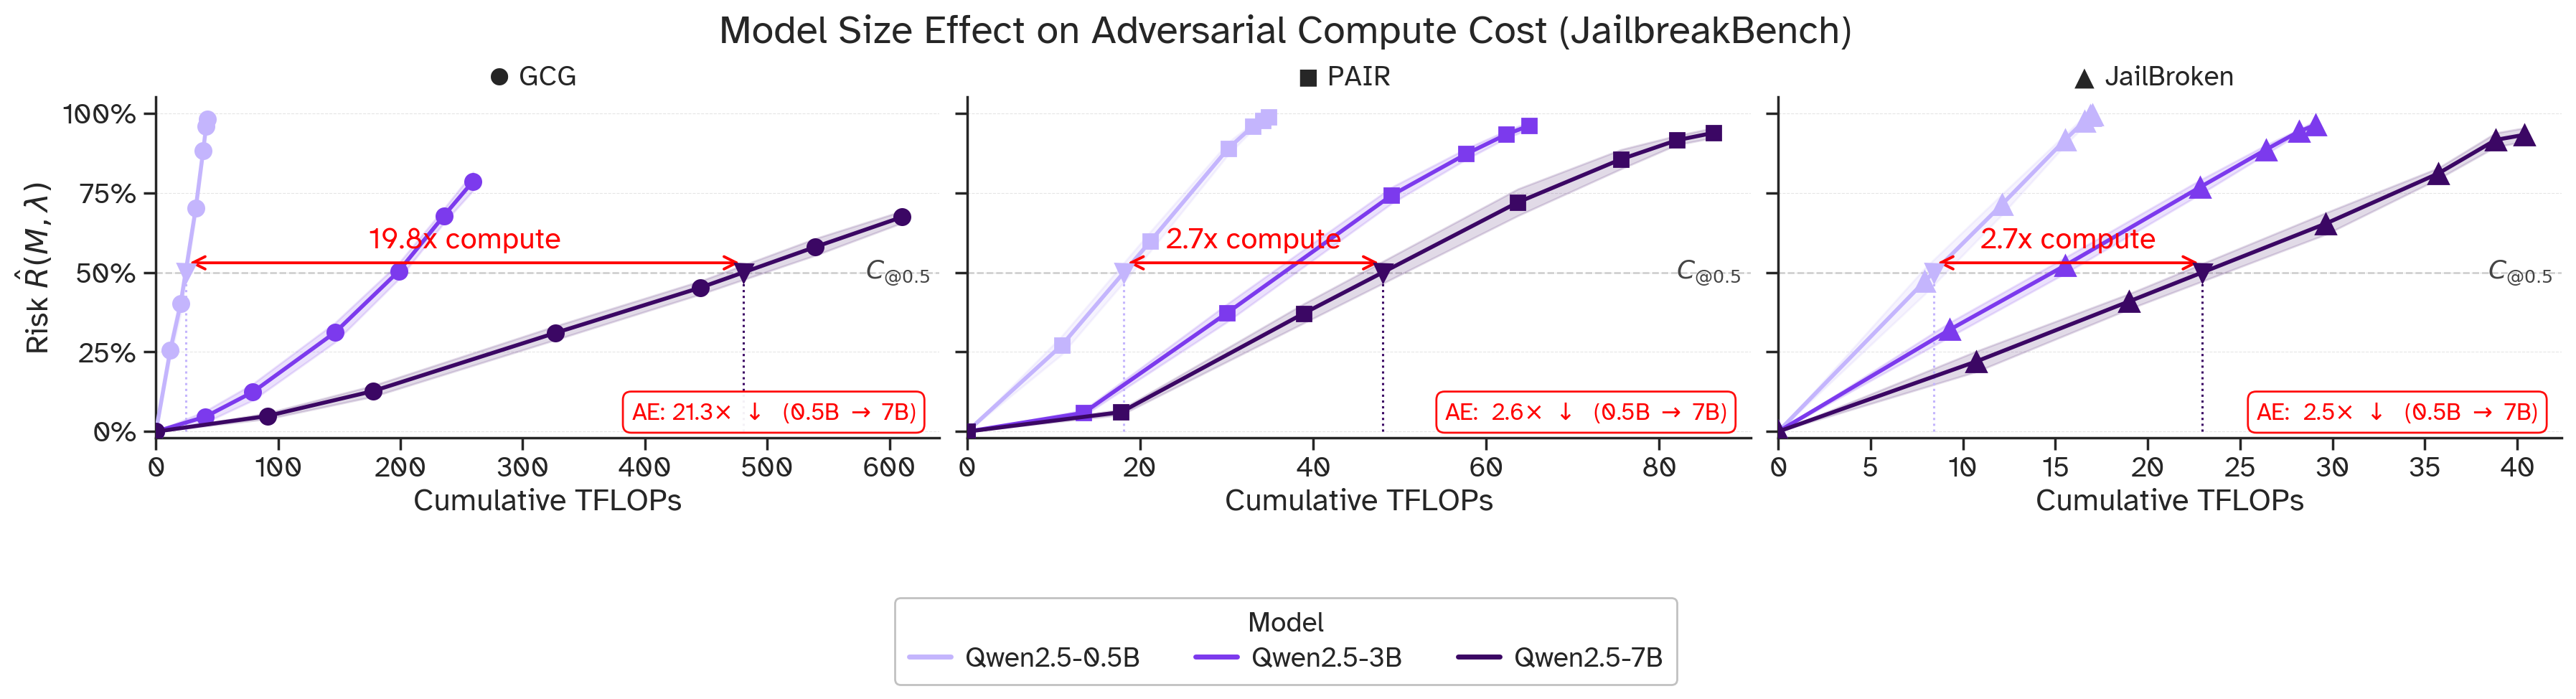

In [43]:
# ── JailbreakBench paths ───────────────────────────────────────────────────────
JBB_CSVS = [
    PLOTS_BASE / "jailbreakbench/qwen2.5-0.5b-instruct/cost/cost_metrics.csv",
    PLOTS_BASE / "jailbreakbench/qwen2.5-3b-instruct/cost/cost_metrics.csv",
    PLOTS_BASE / "jailbreakbench/qwen2.5-7b-instruct/cost/cost_metrics.csv",
]
JBB_OUTPUT_DIR = Path(
    "/Users/malikehehghaghi/Downloads/prisk-pressure/"
    "results/plots/cost/jailbreakbench/ablations/qwen_size/flops"
)
JBB_TITLE = "JailbreakBench — Model Size Effect on Adversarial Compute Cost"

# AE ratios: AE(0.5B) / AE(7B)  →  GCG: 23.4/1.1, PAIR: 28.4/10.9, JB: 58.7/23.1
_AE_LABELS_JBB = {
    "gcg":        r"AE: 21.3$\times$ $\downarrow$  (0.5B $\to$ 7B)",
    "pair":       r"AE:  2.6$\times$ $\downarrow$  (0.5B $\to$ 7B)",
    "jailbroken": r"AE:  2.5$\times$ $\downarrow$  (0.5B $\to$ 7B)",
}

df_jbb_raw = load_cost_csv(JBB_CSVS, skip_missing=SKIP_MISSING)
df_jbb_raw = df_jbb_raw[df_jbb_raw["attack_id"] != "jailbroken-v1"]
if FILTER_ATTACKS:
    df_jbb_raw = df_jbb_raw[df_jbb_raw["attack_id"].isin(FILTER_ATTACKS)]

df_jbb_agg = aggregate_seeds(df_jbb_raw)
n_jbb_base = df_jbb_raw["model_id"].apply(_base).nunique()
print(
    f"JBB: {len(df_jbb_raw):,} rows — {n_jbb_base} base model(s), "
    f"{df_jbb_raw['attack_id'].nunique()} attack(s)  [x-axis: {X_AXIS}]"
)

# Temporarily swap globals so show_comparison uses JBB config
_AE_LABELS_orig, _AE_LABELS = _AE_LABELS, _AE_LABELS_JBB
OUTPUT_DIR_orig, OUTPUT_DIR   = OUTPUT_DIR, JBB_OUTPUT_DIR

if n_jbb_base > 1:
    show_comparison(df_jbb_agg, suptitle=JBB_TITLE)

# Restore HarmBench globals
_AE_LABELS, OUTPUT_DIR = _AE_LABELS_orig, OUTPUT_DIR_orig


## Training Stage Effect — HarmBench (Tulu3 8B)
Compares Base → SFT → DPO → RLVR training stages using Tulu-pink shades.
Arrow spans Base (least robust) → RLVR (most robust).

Tulu3 HB: 840 rows — 4 stage(s), 3 attack(s)
  Saved: /Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/cost/harmbench/ablations/tulu3_training_stage/flops/cost_comparison_all.png


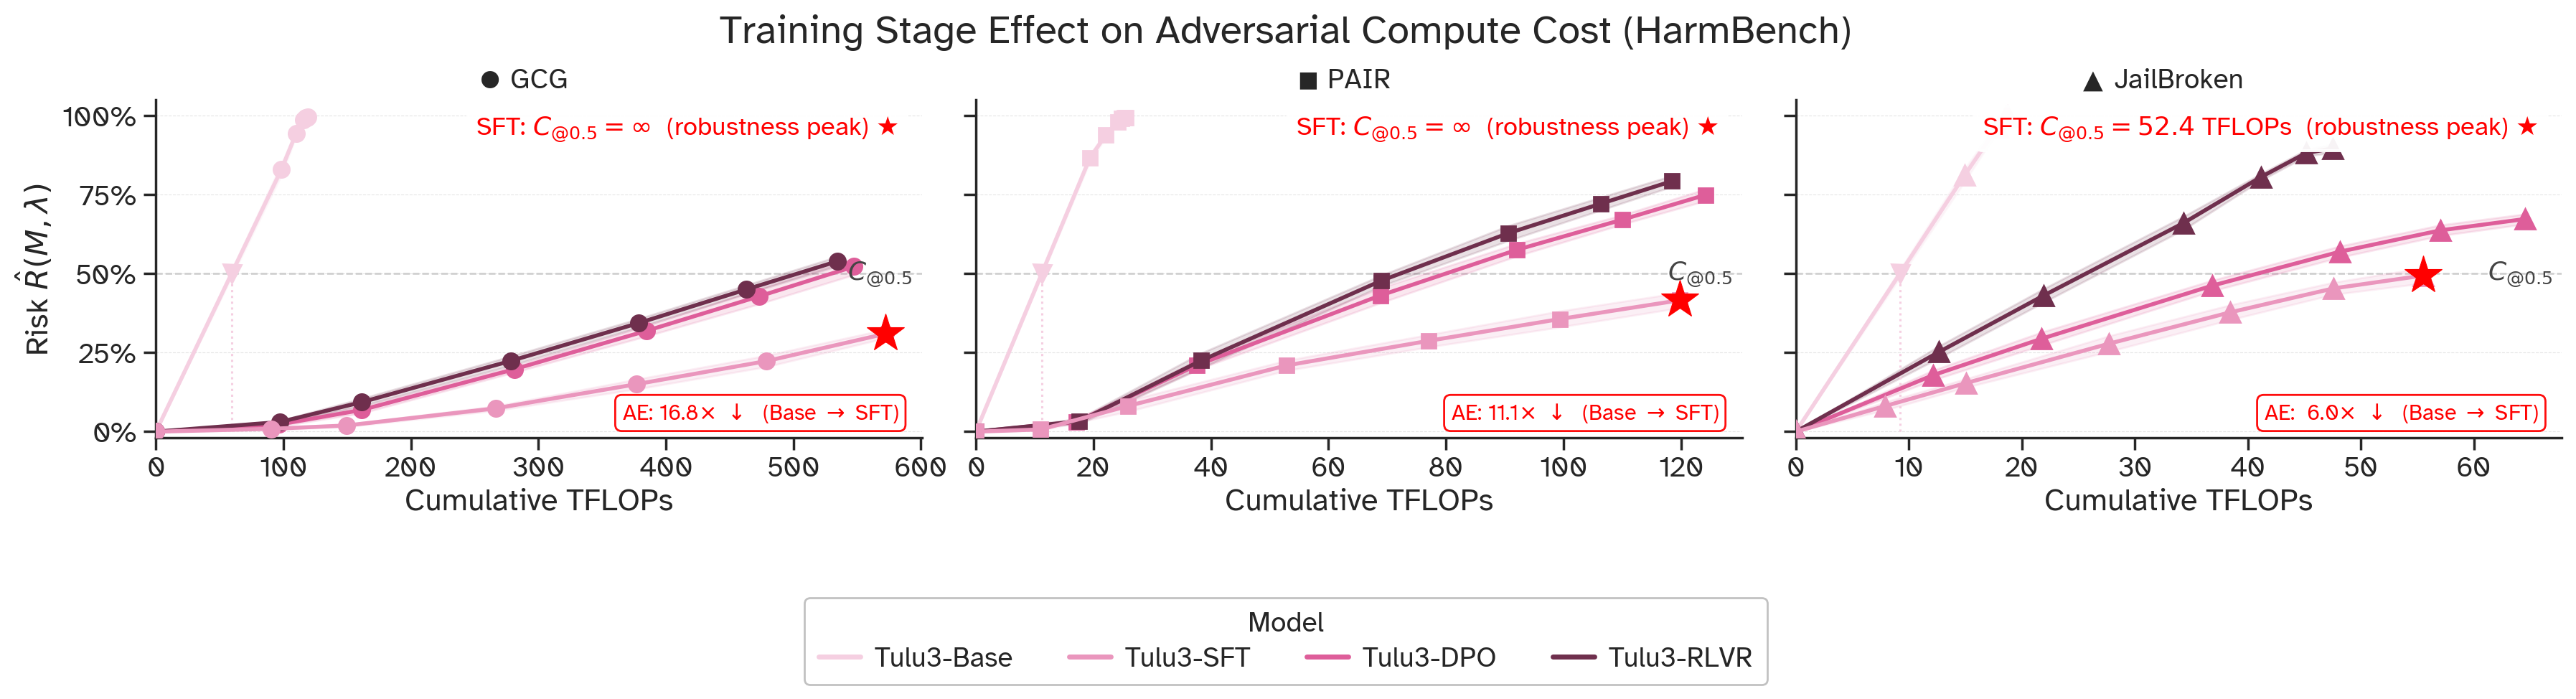

In [44]:
# ── Tulu pink palette anchored on the Tulu3 logo color RGB(222, 94, 154) ──────
# Shades derived by blending toward white (light) / black (dark) along the same hue:
#   #F5CFE1  Base    — 70 % blend toward white
#   #EA96BD  SFT     — 35 % blend toward white
#   #DE5E9A  DPO     — exact Tulu3 logo color
#   #6F2F4D  RLVR    — 50 % blend toward black
TULU_PINKS = ["#F5CFE1", "#EA96BD", "#DE5E9A", "#6F2F4D"]

def tulu_color_map(models: list) -> dict:
    stage_order = {"tulu3-8b-base": 0, "tulu3-8b-sft": 1,
                   "tulu3-8b-dpo": 2, "tulu3-8b-rlvr": 3}
    ordered = sorted(models, key=lambda m: stage_order.get(m, 99))
    n = len(ordered)
    indices = [round(i * (len(TULU_PINKS) - 1) / max(n - 1, 1)) for i in range(n)]
    return {m: TULU_PINKS[idx] for m, idx in zip(ordered, indices)}

_TULU_STAGE_ORDER = {
    "tulu3-8b-base": 0, "tulu3-8b-sft": 1,
    "tulu3-8b-dpo": 2, "tulu3-8b-rlvr": 3,
}

# ── HarmBench annotation data (from Table 1) ─────────────────────────────────
# SFT C@0.5 = ∞ for GCG/PAIR; finite 52.4 TFLOPs for JailBroken
_TULU_HB_TRUE_INF    = {"tulu3-8b-sft": {"gcg", "pair"}}
_TULU_HB_PEAK_FINITE = {"tulu3-8b-sft": {"jailbroken": 52.4}}

# ── JailbreakBench annotation data (from Table 1) ────────────────────────────
# SFT C@0.5 = ∞ for GCG/PAIR; finite 51.8 TFLOPs for JailBroken
_TULU_JBB_TRUE_INF    = {"tulu3-8b-sft": {"gcg", "pair"}}
_TULU_JBB_PEAK_FINITE = {"tulu3-8b-sft": {"jailbroken": 51.8}}


def _make_tulu_annotator(true_inf: dict, peak_finite: dict):
    """
    Factory — returns an annotate_fn for the Tulu3 training-stage block.

    true_inf:    {model_id: {attack_id, ...}} — attacks where C@0.5 = ∞
    peak_finite: {model_id: {attack_id: val}} — attacks where C@0.5 is finite peak
    """
    def _annotate(ax, df_a, ordered_models, col, color_map, attack, target=0.5):
        c_vals = {m: _interp_c_at_risk(df_a[df_a["model_id"] == m], col, target)
                  for m in ordered_models}

        ax.axhline(target, color="#cccccc", linewidth=0.9, linestyle="--", zorder=1)
        ax.text(0.988, target, r"$C_{@0.5}$",
                transform=ax.get_yaxis_transform(),
                va="center", ha="right", fontsize=13, color="#444444", fontweight="bold")

        # Vlines for Base + SFT; SFT skipped when truly ∞
        for m in ordered_models:
            if m not in {"tulu3-8b-base", "tulu3-8b-sft"}:
                continue
            if attack in true_inf.get(m, set()):
                continue
            c = c_vals[m]
            if c is None:
                continue
            color = color_map[m]
            ax.vlines(c, 0, target, color=color, linewidth=1.1, linestyle=":", zorder=2)
            ax.plot(c, target, marker="v", color=color, markersize=9, zorder=6, clip_on=False)

        # Red ★ at the last SFT data point
        sft_m = next((m for m in ordered_models if "sft" in m), None)
        if sft_m is not None:
            df_sft = df_a[df_a["model_id"] == sft_m].sort_values(col)
            if not df_sft.empty:
                lx, ly = float(df_sft[col].iloc[-1]), float(df_sft["risk"].iloc[-1])
                ax.plot(lx, ly, marker="*", color=_ANNOT_COLOR,
                        markersize=20, zorder=8, clip_on=False,
                        markeredgewidth=0.4, markeredgecolor=_ANNOT_COLOR)

        # ∞ badges — top-right, red
        for i, m in enumerate(m for m in ordered_models
                               if attack in true_inf.get(m, set())):
            stage = m.split("-")[-1].upper()
            ax.text(0.97, 0.96 - i * 0.14,
                    rf"{stage}: $C_{{@0.5}} = \infty$  (robustness peak) $\bigstar$",
                    transform=ax.transAxes, va="top", ha="right",
                    fontsize=13, color=_ANNOT_COLOR, fontweight="bold",
                    clip_on=False,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="white", alpha=0.95, linewidth=1.5))

        # Finite-peak badge — top-right, red
        for m in ordered_models:
            fm = peak_finite.get(m, {})
            if attack not in fm:
                continue
            stage = m.split("-")[-1].upper()
            ax.text(0.97, 0.96,
                    rf"{stage}: $C_{{@0.5}} = {fm[attack]}$ TFLOPs  (robustness peak) $\bigstar$",
                    transform=ax.transAxes, va="top", ha="right",
                    fontsize=13, color=_ANNOT_COLOR, fontweight="bold",
                    clip_on=False,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="white", alpha=0.95, linewidth=1.5))

        # AE label — bottom-right, red
        if attack in _AE_LABELS:
            ax.text(0.97, 0.04, _AE_LABELS[attack],
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=11, color=_ANNOT_COLOR, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor=_ANNOT_COLOR, alpha=0.95))
    return _annotate


_annotate_tulu_hb = _make_tulu_annotator(_TULU_HB_TRUE_INF, _TULU_HB_PEAK_FINITE)

# ── HarmBench Tulu3 data + plot ───────────────────────────────────────────────
TULU_HB_CSVS = [
    PLOTS_BASE / "harmbench/tulu3-8b-base/cost/cost_metrics.csv",
    PLOTS_BASE / "harmbench/tulu3-8b-sft/cost/cost_metrics.csv",
    PLOTS_BASE / "harmbench/tulu3-8b-dpo/cost/cost_metrics.csv",
    PLOTS_BASE / "harmbench/tulu3-8b-rlvr/cost/cost_metrics.csv",
]
TULU_HB_OUTPUT_DIR = Path(
    "/Users/malikehehghaghi/Downloads/prisk-pressure/"
    "results/plots/cost/harmbench/ablations/tulu3_training_stage/flops"
)
TULU_HB_TITLE = "Training Stage Effect on Adversarial Compute Cost (HarmBench)"

# AE(Base) / AE(SFT): GCG 8.4/0.5=16.8×, PAIR 39.0/3.5=11.1×, JB 53.3/8.9=6.0×
_AE_LABELS_TULU_HB = {
    "gcg":        r"AE: 16.8$\times$ $\downarrow$  (Base $\to$ SFT)",
    "pair":       r"AE: 11.1$\times$ $\downarrow$  (Base $\to$ SFT)",
    "jailbroken": r"AE:  6.0$\times$ $\downarrow$  (Base $\to$ SFT)",
}

df_tulu_hb_raw = load_cost_csv(TULU_HB_CSVS, skip_missing=SKIP_MISSING)
df_tulu_hb_raw = df_tulu_hb_raw[df_tulu_hb_raw["attack_id"] != "jailbroken-v1"]
if FILTER_ATTACKS:
    df_tulu_hb_raw = df_tulu_hb_raw[df_tulu_hb_raw["attack_id"].isin(FILTER_ATTACKS)]

df_tulu_hb_agg = aggregate_seeds(df_tulu_hb_raw)
n_tulu_hb_base = df_tulu_hb_raw["model_id"].apply(_base).nunique()
print(f"Tulu3 HB: {len(df_tulu_hb_raw):,} rows — {n_tulu_hb_base} stage(s), "
      f"{df_tulu_hb_raw['attack_id'].nunique()} attack(s)")

_AE_LABELS_orig, _AE_LABELS = _AE_LABELS, _AE_LABELS_TULU_HB
OUTPUT_DIR_orig, OUTPUT_DIR   = OUTPUT_DIR, TULU_HB_OUTPUT_DIR

if n_tulu_hb_base > 1:
    show_comparison(df_tulu_hb_agg, suptitle=TULU_HB_TITLE,
                    color_map_fn=tulu_color_map, model_order=_TULU_STAGE_ORDER,
                    annotate_fn=_annotate_tulu_hb)

_AE_LABELS, OUTPUT_DIR = _AE_LABELS_orig, OUTPUT_DIR_orig


/var/folders/d7/6swf_cn561v8n6hw_bgg04lh0000gn/T/ipykernel_85416/3633403404.py:62: UserWarning: The figure layout has changed to tight
  fig_ts_hb.tight_layout(pad=0.5, rect=[0, 0.18, 1, 1])


  Saved: /Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/cost/harmbench/ablations/tulu3_training_stage/flops/cost_comparison_gcg_jailbroken.png


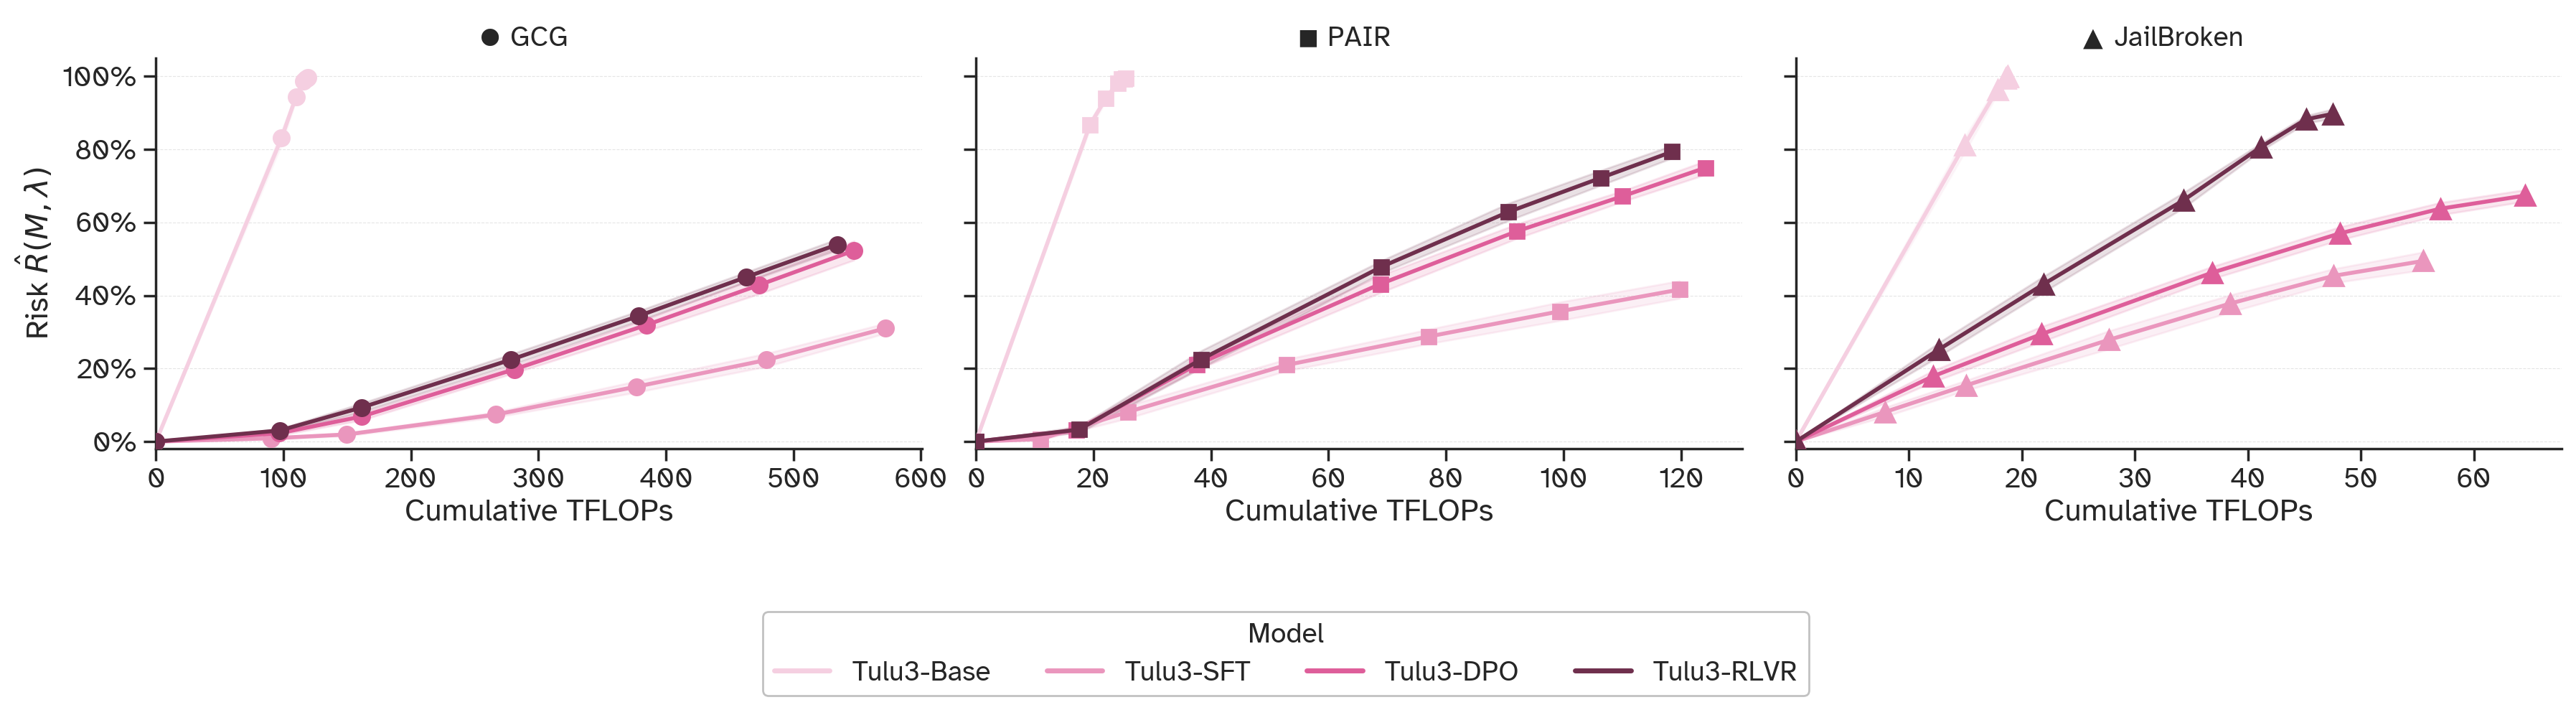

In [45]:
# ── Training Stage Effect (HarmBench): GCG vs JailBroken side-by-side ─────────
# 3-panel figure: GCG | PAIR | JailBroken.
# Strips robustness-peak / start / AE annotations; retains C@0.5 reference line.

_ts_hb_attacks = ['gcg', 'pair', 'jailbroken']
_df_ts_hb      = df_tulu_hb_agg[df_tulu_hb_agg['attack_id'].isin(_ts_hb_attacks)]
_col_ts_hb     = _xcol(X_AXIS)

_ordered_ts_hb = sorted(_df_ts_hb['model_id'].unique(),
                         key=lambda m: _TULU_STAGE_ORDER.get(m, 99))
_cmap_ts_hb    = tulu_color_map(_ordered_ts_hb)

fig_ts_hb, axes_ts_hb = plt.subplots(
    1, len(_ts_hb_attacks), figsize=(6 * len(_ts_hb_attacks), 4.5),
    sharey=True, layout='constrained'
)

_atk_marker_map_ts_hb = {}
for ax, attack in zip(axes_ts_hb, _ts_hb_attacks):
    df_a  = _df_ts_hb[_df_ts_hb['attack_id'] == attack]
    x_max = float(df_a[_col_ts_hb].max()) if not df_a.empty else 1.0
    marker = _ATTACK_MARKERS.get(attack, 'o')
    msize  = _MARKER_SIZES.get(marker, 8)
    _atk_marker_map_ts_hb[attack] = marker

    for model in _ordered_ts_hb:
        df_m = df_a[df_a['model_id'] == model].sort_values(_col_ts_hb)
        if df_m.empty:
            continue
        ax.plot(df_m[_col_ts_hb], df_m['risk'],
                color=_cmap_ts_hb[model], marker=marker,
                linestyle='-', linewidth=2.0, markersize=msize, zorder=3)
        if 'n_seeds' in df_m.columns and (df_m['n_seeds'] > 1).any():
            ax.fill_between(df_m[_col_ts_hb], df_m['risk_lower'], df_m['risk_upper'],
                            color=_cmap_ts_hb[model], alpha=0.15, zorder=2)

    # ax.axhline(0.5, color='#cccccc', linewidth=0.9, linestyle='--', zorder=1)
    # ax.text(1.01, 0.5, r"$C_{@0.5}$",
    #         transform=ax.get_yaxis_transform(),
    #         va='center', ha='right', fontsize=13, color='#444444', fontweight='bold')

    base_title = _ATTACK_TITLES.get(attack, _attack_label(attack))
    _style_axes(ax, base_title, x_max, X_AXIS)
    ax.title.set_fontsize(14)
    ax.title.set_fontweight('bold')

axes_ts_hb[1].set_ylabel('')
axes_ts_hb[2].set_ylabel('')


legend_handles_ts_hb = [
    Line2D([0], [0], color=_cmap_ts_hb[m], linewidth=2.5)
    for m in _ordered_ts_hb
]
leg_ts_hb = fig_ts_hb.legend(
    legend_handles_ts_hb, [_model_label(m) for m in _ordered_ts_hb],
    title='Model', loc='lower center', bbox_to_anchor=(0.5, -0.08),
    ncols=len(_ordered_ts_hb), fontsize=14, title_fontsize=14,
    frameon=True, facecolor='white', edgecolor='#bbbbbb', framealpha=0.9,
)

fig_ts_hb.tight_layout(pad=0.5, rect=[0, 0.18, 1, 1])
fig_ts_hb.canvas.draw()

renderer_ts_hb    = fig_ts_hb.canvas.get_renderer()
disp_to_fig_ts_hb = fig_ts_hb.transFigure.inverted()
gap_px_ts_hb      = 5 * fig_ts_hb.dpi / 72

for ax, attack in zip(axes_ts_hb, _ts_hb_attacks):
    marker = _atk_marker_map_ts_hb[attack]
    glyph  = _MARKER_GLYPH.get(marker, '')
    if not glyph:
        continue
    title_bbox = ax.title.get_window_extent(renderer=renderer_ts_hb)
    gx, gy = disp_to_fig_ts_hb.transform(
        (title_bbox.x0 - gap_px_ts_hb,
         (title_bbox.y0 + title_bbox.y1) / 2)
    )
    fig_ts_hb.text(gx, gy, glyph,
                   fontsize=_GLYPH_FS.get(marker, 15), fontweight='bold',
                   ha='right', va='center')

_save(fig_ts_hb, TULU_HB_OUTPUT_DIR / f'cost_comparison_gcg_jailbroken.{FMT}',
      extra_artists=(leg_ts_hb,))
plt.show()


## Attack Transfer — HarmBench (Qwen2.5 0.5B → Qwen3-8B)
GCG suffix optimized on Qwen2.5-0.5B applied to Qwen3-8B without re-optimization.
Source curve: native GCG on 0.5B (surrogate).  Target curve: transferred suffix on Qwen3-8B.

Transfer HB (0.5B to Qwen3-8B): 133 rows -- 2 model(s)  [x-axis: flops]
  Saved: /Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/cost/harmbench/ablations/attack_transfer_gcg/flops/cost_comparison_all.png


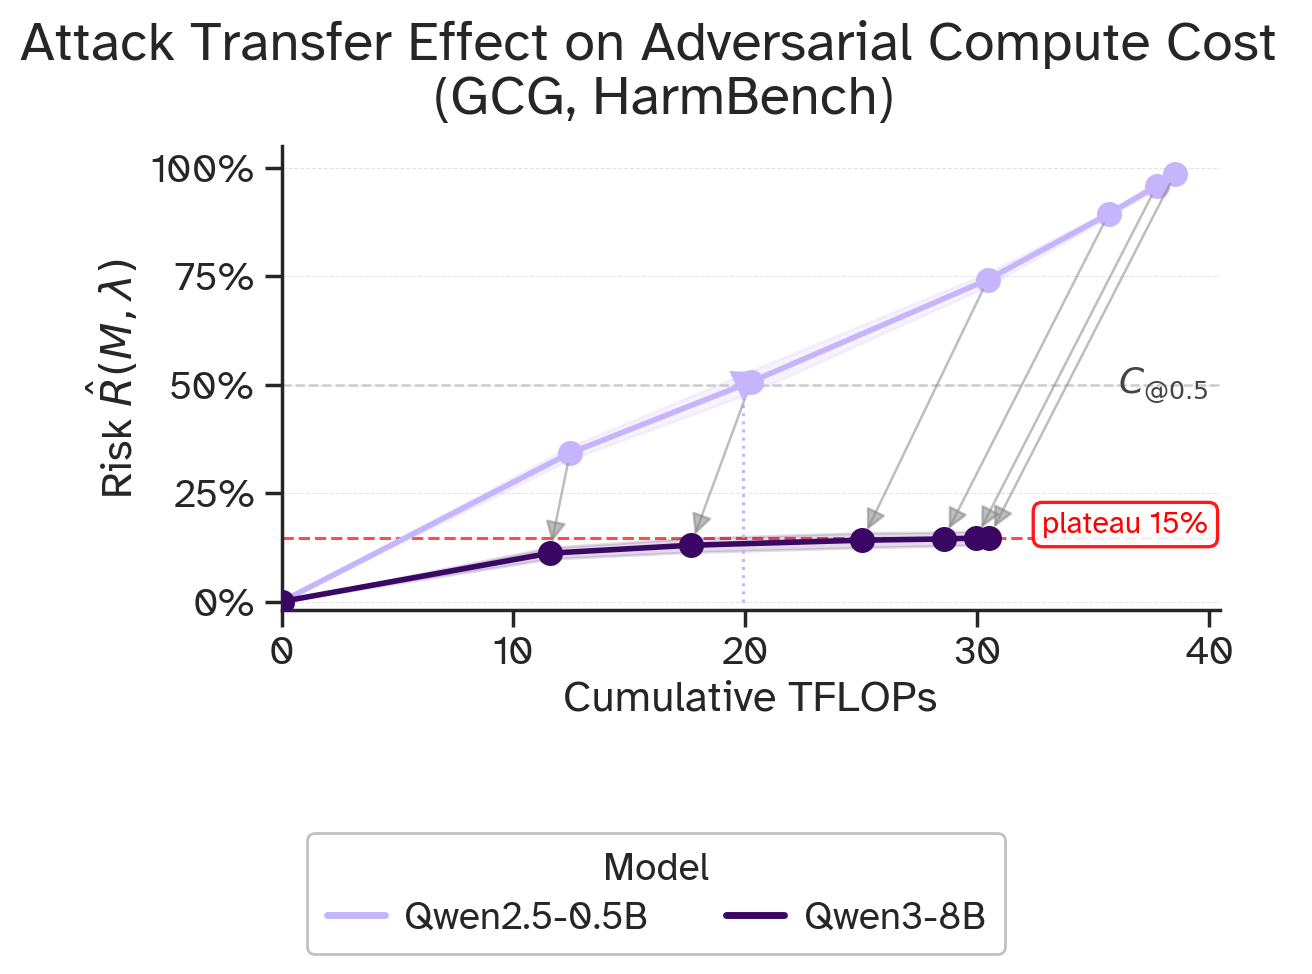

In [46]:
# ── Attack Transfer: Qwen2.5 0.5B (source) → Qwen3-8B (target) ───────────────
# GCG suffix optimized on 0.5B applied to Qwen3-8B without re-optimization.
# Source: native GCG on 0.5B.  Target: transferred suffix on Qwen3-8B.

_TRANSFER_0p5B_CSV = PLOTS_BASE / "harmbench/qwen2.5-0.5b-instruct/cost/cost_metrics.csv"
_TRANSFER_Q3_CSV   = PLOTS_BASE / "harmbench/qwen3-8b/cost/cost_metrics.csv"

TRANSFER_HB_OUTPUT_DIR = Path(
    "/Users/malikehehghaghi/Downloads/prisk-pressure/"
    "results/plots/cost/harmbench/ablations/attack_transfer_gcg/flops"
)
TRANSFER_HB_TITLE = "Attack Transfer Effect on Adversarial Compute Cost \n (GCG, HarmBench)"

# Source: 0.5B native GCG
df_transfer_src = load_cost_csv([_TRANSFER_0p5B_CSV], skip_missing=SKIP_MISSING)
df_transfer_src = df_transfer_src[df_transfer_src["attack_id"] == "gcg"]

# Target: Qwen3-8B with GCG suffix transferred from 0.5B
_TRANSFER_ATTACK_ID = "transfer_gcg_from_qwen2.5-0.5b-instruct"
df_transfer_tgt = load_cost_csv([_TRANSFER_Q3_CSV], skip_missing=SKIP_MISSING)
df_transfer_tgt = df_transfer_tgt[
    df_transfer_tgt["attack_id"] == _TRANSFER_ATTACK_ID
].copy()
df_transfer_tgt["attack_id"] = "gcg"  # align with source so both appear in one panel

df_transfer_hb_raw = pd.concat([df_transfer_src, df_transfer_tgt], ignore_index=True)
df_transfer_hb_agg = aggregate_seeds(df_transfer_hb_raw)
n_transfer_hb = df_transfer_hb_raw["model_id"].apply(_base).nunique()
print(
    f"Transfer HB (0.5B to Qwen3-8B): {len(df_transfer_hb_raw):,} rows -- "
    f"{n_transfer_hb} model(s)  [x-axis: {X_AXIS}]"
)

# ── Custom annotator ───────────────────────────────────────────────────────────
# Key messages:
#   1. Source (0.5B) hits C@0.5 normally — vline + marker shows where.
#   2. Target (Qwen3-8B) plateaus well below 50%; C@0.5 = ∞.
#      A horizontal dashed line at the plateau risk makes this visually explicit.
#   3. Both curves span a similar compute range (x-axis), so the gap is in
#      effectiveness (y), not in compute budget — the horizontal badge conveys this.
def _annotate_transfer_hb(ax, df_a, ordered_models, col, color_map, attack, target=0.5):
    source_m = "qwen2.5-0.5b-instruct"
    target_m = "qwen3-8b"

    # ── C@0.5 threshold ───────────────────────────────────────────────────────
    ax.axhline(target, color="#cccccc", linewidth=0.9, linestyle="--", zorder=1)
    ax.text(0.988, target, r"$C_{@0.5}$",
            transform=ax.get_yaxis_transform(),
            va="center", ha="right", fontsize=13, color="#444444", fontweight="bold")

    # ── Vline + marker at source C@0.5 ────────────────────────────────────────
    c_src = _interp_c_at_risk(df_a[df_a["model_id"] == source_m], col, target)
    if c_src is not None:
        color_src = color_map[source_m]
        ax.vlines(c_src, 0, target, color=color_src, linewidth=1.1, linestyle=":", zorder=2)
        ax.plot(c_src, target, marker="v", color=color_src, markersize=9, zorder=6, clip_on=False)

    # ── Plateau line for Qwen3-8B ──────────────────────────────────────────────
    df_tgt = df_a[df_a["model_id"] == target_m].sort_values(col)
    if not df_tgt.empty:
        plateau_risk = float(df_tgt["risk"].iloc[-1])   # last (highest-lambda) value
        peak_pct     = int(round(plateau_risk * 100))
        color_tgt    = color_map[target_m]

        # Horizontal dashed plateau line
        ax.axhline(plateau_risk, color=_ANNOT_COLOR, linewidth=1.1,
                   linestyle="--", alpha=0.7, zorder=1)
        # Label at right edge of axis
        ax.text(0.988, plateau_risk,
                f"plateau {peak_pct}%",
                transform=ax.get_yaxis_transform(),
                va="bottom", ha="right", fontsize=11,
                color=_ANNOT_COLOR, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor=_ANNOT_COLOR, linewidth=1.2, alpha=0.9))

    # Connecting arrows: src dot → tgt dot at each shared lambda level
    df_s = df_a[df_a["model_id"] == source_m].sort_values("lambda")
    df_t = df_a[df_a["model_id"] == target_m].sort_values("lambda")
    if not df_s.empty and not df_t.empty:
        merged = df_s[["lambda", col, "risk"]].merge(
            df_t[["lambda", col, "risk"]],
            on="lambda", suffixes=("_src", "_tgt"),
        )
        for _, row in merged.iterrows():
            ax.annotate(
                "",
                xy=(row[f"{col}_tgt"], row["risk_tgt"]),
                xytext=(row[f"{col}_src"], row["risk_src"]),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color="#888888",
                    lw=0.9,
                    alpha=0.55,
                    shrinkA=4, shrinkB=4,
                ),
                zorder=4,
            )
            mx = (row[f"{col}_src"] + row[f"{col}_tgt"]) / 2
            my = (row["risk_src"]   + row["risk_tgt"])   / 2

    # AE label (fill in once computed)
    if attack in _AE_LABELS:
        ax.text(0.97, 0.04, _AE_LABELS[attack],
                transform=ax.transAxes, ha="right", va="bottom",
                fontsize=11, color=_ANNOT_COLOR, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor=_ANNOT_COLOR, alpha=0.95))

# AE(0.5B native GCG) / AE(Qwen3-8B transfer GCG): fill in once computed
_AE_LABELS_TRANSFER_HB = {
    # "gcg": r"AE: X.X$\times$ $\downarrow$  (0.5B $\to$ Qwen3-8B)",
}

OUTPUT_DIR_orig, OUTPUT_DIR = OUTPUT_DIR, TRANSFER_HB_OUTPUT_DIR
_AE_LABELS_orig, _AE_LABELS = _AE_LABELS, _AE_LABELS_TRANSFER_HB

if n_transfer_hb > 1:
    _gcg_title_orig, _ATTACK_TITLES["gcg"] = _ATTACK_TITLES["gcg"], ""
    _gcg_glyph_orig  = _MARKER_GLYPH.pop("o", None)
    show_comparison(df_transfer_hb_agg, suptitle=TRANSFER_HB_TITLE,
                    annotate_fn=_annotate_transfer_hb)
    _ATTACK_TITLES["gcg"] = _gcg_title_orig
    if _gcg_glyph_orig is not None:
        _MARKER_GLYPH["o"] = _gcg_glyph_orig

_AE_LABELS, OUTPUT_DIR = _AE_LABELS_orig, OUTPUT_DIR_orig


## Combined Plot
All models × attacks on a single canvas with external legends.

  Saved: /Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/cost/harmbench/ablations/qwen_size/flops/cost_combined.png


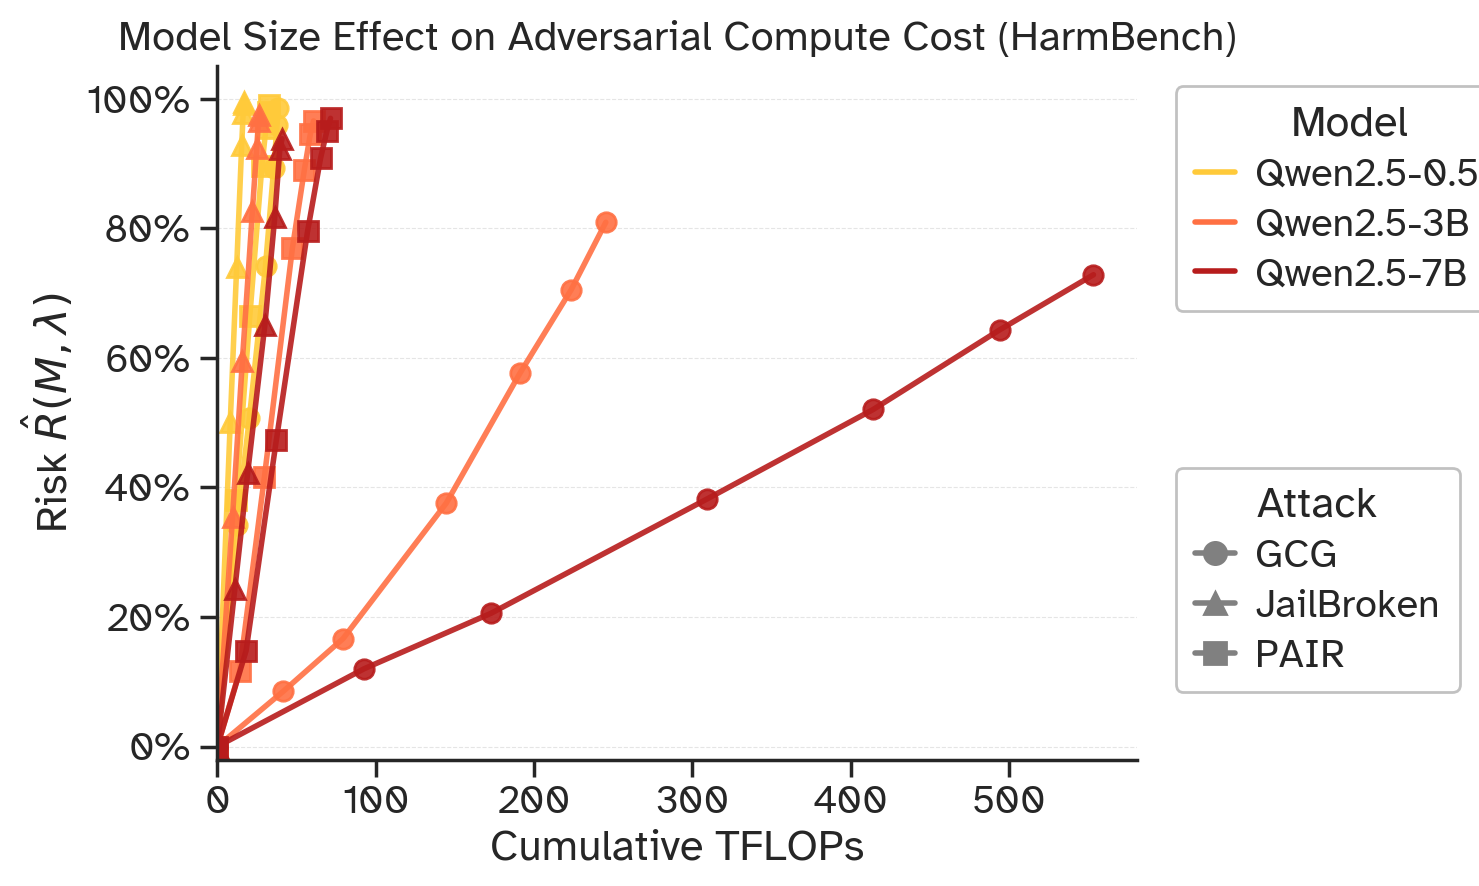

In [47]:
def show_combined(df_agg: pd.DataFrame, x_axis: str = X_AXIS, suptitle: str = TITLE) -> None:
    col       = _xcol(x_axis)
    models    = sorted(df_agg["model_id"].unique())
    attacks   = sorted(df_agg["attack_id"].unique())
    color_map = _model_color(models)
    x_max     = float(df_agg[col].max())

    fig, ax = plt.subplots(figsize=(8, 4.5))

    for model in models:
        for attack in attacks:
            df_p = df_agg[
                (df_agg["model_id"] == model) & (df_agg["attack_id"] == attack)
            ].sort_values(col)
            if df_p.empty:
                continue
            ax.plot(
                df_p[col], df_p["risk"],
                color=color_map[model],
                marker=ATTACK_MARKERS.get(attack, "o"),
                linestyle="-", linewidth=2.0, markersize=7, alpha=0.9,
            )

    _leg_style = dict(
        frameon=True, facecolor="white", edgecolor="#bbbbbb",
        framealpha=0.9, borderpad=0.5, labelspacing=0.4,
        handlelength=1.0, handletextpad=0.5,
    )
    leg1 = ax.legend(
        handles=[
            Line2D([0], [0], color=color_map[m], linestyle="-",
                   linewidth=2.0, label=_model_label(m))
            for m in models
        ],
        title="Model", loc="upper left", bbox_to_anchor=(1.02, 1), **_leg_style,
    )
    ax.add_artist(leg1)
    ax.legend(
        handles=[
            Line2D([0], [0], color="gray", linestyle="-",
                   marker=ATTACK_MARKERS.get(a, "o"),
                   linewidth=2.0, markersize=8, label=_attack_label(a))
            for a in attacks
        ],
        title="Attack", loc="upper left", bbox_to_anchor=(1.02, 0.45), **_leg_style,
    )

    ax_title = _reformat_title(suptitle) if suptitle else "Cost-Risk Curves — All Models & Attacks"
    _style_axes(ax, ax_title, x_max, x_axis)
    fig.subplots_adjust(right=0.70)
    _save(fig, OUTPUT_DIR / f"cost_combined.{FMT}")
    plt.show()


if MODE in ("all", "comparison") and n_base > 1:
    show_combined(df_agg)

## Per-Model Aggregated Plots
One figure per base model; one line per attack with CI fill.

In [48]:
def show_model_aggregated(df_agg: pd.DataFrame, x_axis: str = X_AXIS) -> None:
    col     = _xcol(x_axis)
    models  = sorted(df_agg["model_id"].unique())
    attacks = sorted(df_agg["attack_id"].unique())
    atk_colors = {a: PALETTE[i % len(PALETTE)] for i, a in enumerate(attacks)}

    for model in models:
        df_m  = df_agg[df_agg["model_id"] == model]
        x_max = float(df_m[col].max()) if not df_m.empty else 1.0

        fig, ax = plt.subplots(figsize=(7, 5))
        for attack in attacks:
            df_a = df_m[df_m["attack_id"] == attack].sort_values(col)
            if df_a.empty:
                continue
            color = atk_colors[attack]
            n_s   = int(df_a["n_seeds"].max()) if "n_seeds" in df_a.columns else 1
            ax.plot(
                df_a[col], df_a["risk"],
                color=color, label=f"{_attack_label(attack)} (n={n_s})",
                marker=ATTACK_MARKERS.get(attack, "o"),
                linestyle="-", linewidth=1.8, markersize=8, zorder=3,
            )
            if "n_seeds" in df_a.columns and (df_a["n_seeds"] > 1).any():
                ax.fill_between(
                    df_a[col], df_a["risk_lower"], df_a["risk_upper"],
                    color=color, alpha=0.18, zorder=2,
                )

        _style_axes(ax, f"Cost-Risk Curves \u2014 {_model_label(model)}", x_max, x_axis)
        ax.legend(
            title="Attack",
            loc="upper center", bbox_to_anchor=(0.5, -0.18),
            ncols=len(attacks), frameon=False, borderpad=0.6, labelspacing=0.4,
        )
        fig.tight_layout(pad=0.5)
        safe_m = model.replace("/", "_")
        _save(fig, OUTPUT_DIR / f"cost_aggregated_{safe_m}.{FMT}")
        plt.show()


if MODE in ("all", "aggregated"):
    show_model_aggregated(df_agg)

## Per-Seed Trace Plots
One figure per (base model × attack); individual seeds as faint lines, mean ± 95 % CI overlaid.

In [49]:
def show_per_seed_traces(
    df_raw: pd.DataFrame, df_agg: pd.DataFrame, x_axis: str = X_AXIS
) -> None:
    col       = _xcol(x_axis)
    df_raw    = df_raw.copy()
    df_raw["_base"] = df_raw["model_id"].apply(_base)
    seed_color = PALETTE[0]

    for bm in sorted(df_raw["_base"].unique()):
        df_bm  = df_raw[df_raw["_base"] == bm]
        seeds  = sorted(df_bm["model_id"].unique())
        n_seeds = len(seeds)

        for attack in sorted(df_bm["attack_id"].unique()):
            df_a = df_bm[df_bm["attack_id"] == attack]
            if df_a.empty:
                continue

            fig, ax = plt.subplots(figsize=(7, 5))

            for seed in seeds:
                ds = df_a[df_a["model_id"] == seed].sort_values(col)
                if ds.empty:
                    continue
                ax.plot(
                    ds[col], ds["risk"],
                    color=seed_color, alpha=0.20, linewidth=0.9,
                    marker=ATTACK_MARKERS.get(attack, "o"), markersize=3, zorder=2,
                )

            df_mean = df_agg[
                (df_agg["model_id"] == bm) & (df_agg["attack_id"] == attack)
            ].sort_values(col)
            if not df_mean.empty:
                ax.plot(
                    df_mean[col], df_mean["risk"],
                    color="#1a1a2e", linewidth=2.2,
                    marker=ATTACK_MARKERS.get(attack, "o"), markersize=5, zorder=5,
                )
                ax.fill_between(
                    df_mean[col], df_mean["risk_lower"], df_mean["risk_upper"],
                    color="#1a1a2e", alpha=0.15, zorder=4,
                )

            x_max = float(df_a[col].max())
            _style_axes(ax, f"{bm} \u2014 {_attack_label(attack)}", x_max, x_axis)
            ax.legend(
                handles=[
                    Line2D([0], [0], color=seed_color, alpha=0.5, linewidth=1.2,
                           marker=ATTACK_MARKERS.get(attack, "o"), markersize=3,
                           label=f"Individual seeds (n={n_seeds})"),
                    Line2D([0], [0], color="#1a1a2e", linewidth=2.2,
                           marker=ATTACK_MARKERS.get(attack, "o"), markersize=5,
                           label="Mean \u00b1 95% CI"),
                ],
                fontsize=13, loc="lower right", framealpha=0.9,
                borderpad=0.8, labelspacing=0.4,
            )
            fig.tight_layout(pad=0.5)
            safe_bm = bm.replace("/", "_")
            _save(fig, OUTPUT_DIR / f"cost_seeds_{safe_bm}_{attack}.{FMT}")
            plt.show()


if MODE in ("all", "per-seed"):
    show_per_seed_traces(df_raw, df_agg)

## Attack Transfer (HarmBench)
GCG transfer risk curves

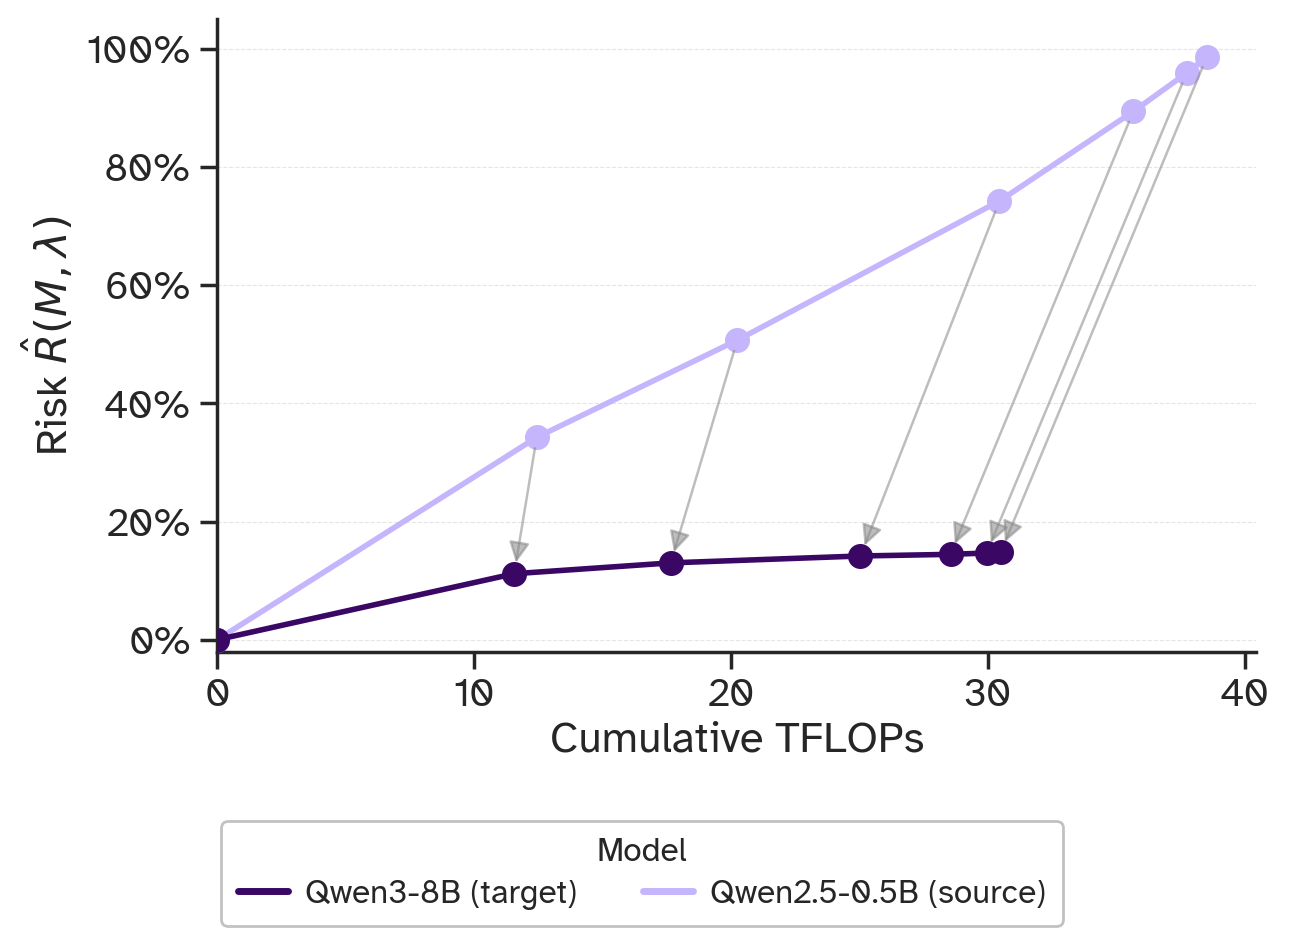

In [50]:
# ── Attack transfer risk curves (HarmBench) ──────────────────────────────────
# GCG suffix optimised on Qwen2.5-0.5B, transferred to Qwen3-8B.

from matplotlib.lines import Line2D as _L2D

_SIDEBY_OUTPUT_DIR = Path(
    "/Users/malikehehghaghi/Downloads/prisk-pressure/"
    "results/plots/cost/harmbench/ablations/attack_transfer_gcg/flops"
)

_xcol_sb = _xcol(X_AXIS)
_SRC     = "qwen2.5-0.5b-instruct"
_TGT     = "qwen3-8b"
_col_map = qwen_color_map([_SRC, _TGT])

fig, ax_risk = plt.subplots(1, 1, figsize=(6.5, 4.5))

df_at = df_transfer_hb_agg[df_transfer_hb_agg["attack_id"] == "gcg"]

for model in [_SRC, _TGT]:
    df_m = df_at[df_at["model_id"] == model].sort_values(_xcol_sb)
    if df_m.empty:
        continue
    ax_risk.plot(df_m[_xcol_sb], df_m["risk"],
                 color=_col_map[model], linestyle="-", marker="o",
                 markersize=8, linewidth=2.0, zorder=3)

_df_s_sb = df_at[df_at["model_id"] == _SRC].sort_values("lambda")
_df_t_sb = df_at[df_at["model_id"] == _TGT].sort_values("lambda")
if not _df_s_sb.empty and not _df_t_sb.empty:
    _mg = _df_s_sb[["lambda", _xcol_sb, "risk"]].merge(
        _df_t_sb[["lambda", _xcol_sb, "risk"]],
        on="lambda", suffixes=("_src", "_tgt"),
    )
    for _, row in _mg.iterrows():
        ax_risk.annotate(
            "",
            xy=(row[f"{_xcol_sb}_tgt"], row["risk_tgt"]),
            xytext=(row[f"{_xcol_sb}_src"], row["risk_src"]),
            arrowprops=dict(arrowstyle="-|>", color="#888888",
                            lw=0.9, alpha=0.55, shrinkA=4, shrinkB=4),
            zorder=4,
        )

_style_axes(ax_risk, "", float(df_at[_xcol_sb].max()), X_AXIS)

fig.tight_layout(pad=0.5, rect=[0, 0.13, 1, 1])
_leg_hb = fig.legend(
    handles=[
        _L2D([], [], color=_col_map[_TGT], linestyle="-",
             linewidth=2.5, label="Qwen3-8B (target)"),
        _L2D([], [], color=_col_map[_SRC], linestyle="-",
             linewidth=2.5, label="Qwen2.5-0.5B (source)"),
    ],
    title="Model", loc="lower center", bbox_to_anchor=(0.5, -0.05),
    ncols=2, fontsize=12, title_fontsize=12,
    frameon=True, facecolor="white", edgecolor="#bbbbbb", framealpha=0.9,
    borderpad=0.5, labelspacing=0.4, handlelength=1.5, handletextpad=0.5,
)
# _sup_hb = fig.suptitle("GCG Attack Transfer (HarmBench)", fontsize=20, fontweight="bold")
# _save(fig, _SIDEBY_OUTPUT_DIR / f"cost_transfer_sidebyside.{FMT}",
#       extra_artists=(_sup_hb, _leg_hb))
plt.show()


## Attack Transfer (JailbreakBench)
Same as HarmBench: GCG transfer risk curves 

JBB transfer: 14 agg rows
  Saved: /Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/cost/jailbreakbench/ablations/attack_transfer_gcg/flops/cost_transfer_sidebyside.png


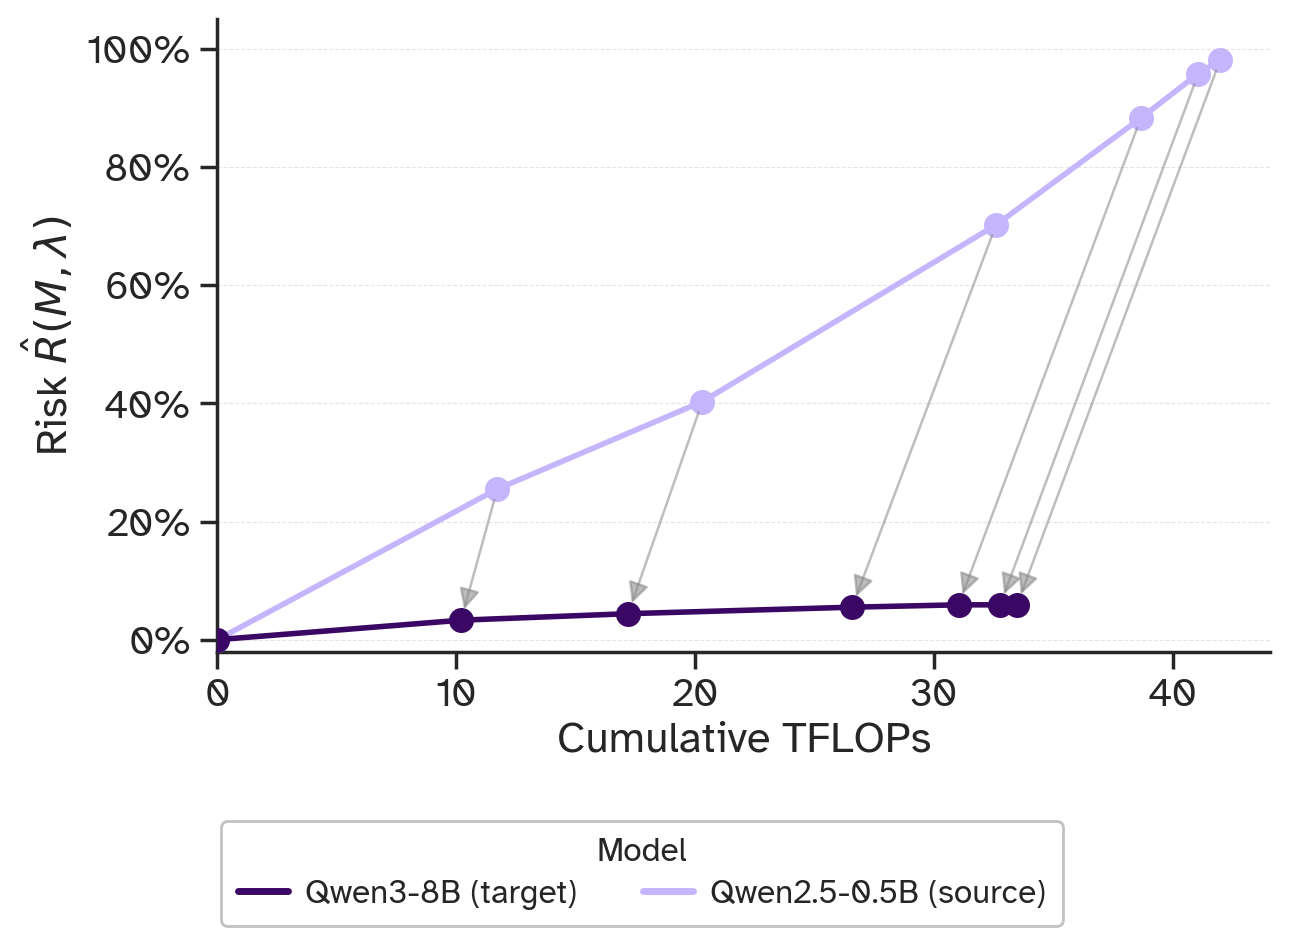

In [51]:
# ── Attack transfer risk curves (JailbreakBench) ─────────────────────────────
from matplotlib.lines import Line2D as _L2D_JBB

_JBB_BASE  = PLOTS_BASE
_JBB_SRC   = "qwen2.5-0.5b-instruct"
_JBB_TGT   = "qwen3-8b"
_JBB_ATK   = "transfer_gcg_from_qwen2.5-0.5b-instruct"
_xcol_jbb  = _xcol(X_AXIS)

_SIDEBY_JBB_OUTPUT_DIR = Path(
    "/Users/malikehehghaghi/Downloads/prisk-pressure/"
    "results/plots/cost/jailbreakbench/ablations/attack_transfer_gcg/flops"
)

_jbb_q3_raw = load_cost_csv(
    [_JBB_BASE / "jailbreakbench/qwen3-8b/cost/cost_metrics.csv"],
    skip_missing=SKIP_MISSING,
)
_jbb_q3_raw = _jbb_q3_raw[_jbb_q3_raw["attack_id"] == _JBB_ATK].copy()
_jbb_q3_raw["attack_id"] = "gcg"

_jbb_p5b_raw = load_cost_csv(
    [_JBB_BASE / "jailbreakbench/qwen2.5-0.5b-instruct/cost/cost_metrics.csv"],
    skip_missing=SKIP_MISSING,
)
_jbb_p5b_raw = _jbb_p5b_raw[_jbb_p5b_raw["attack_id"] == "gcg"]

_jbb_agg     = aggregate_seeds(pd.concat([_jbb_q3_raw, _jbb_p5b_raw], ignore_index=True))
_jbb_col_map = qwen_color_map([_JBB_SRC, _JBB_TGT])
print(f"JBB transfer: {len(_jbb_agg)} agg rows")

fig_jbb, ax_risk_jbb = plt.subplots(1, 1, figsize=(6.5, 4.5))

_df_at_jbb = _jbb_agg[_jbb_agg["attack_id"] == "gcg"]

for _model in [_JBB_SRC, _JBB_TGT]:
    _dm = _df_at_jbb[_df_at_jbb["model_id"] == _model].sort_values(_xcol_jbb)
    if _dm.empty:
        continue
    ax_risk_jbb.plot(_dm[_xcol_jbb], _dm["risk"],
                     color=_jbb_col_map[_model], linestyle="-", marker="o",
                     markersize=8, linewidth=2.0, zorder=3)

_df_s_jbb = _df_at_jbb[_df_at_jbb["model_id"] == _JBB_SRC].sort_values("lambda")
_df_t_jbb = _df_at_jbb[_df_at_jbb["model_id"] == _JBB_TGT].sort_values("lambda")
if not _df_s_jbb.empty and not _df_t_jbb.empty:
    _mg_jbb = _df_s_jbb[["lambda", _xcol_jbb, "risk"]].merge(
        _df_t_jbb[["lambda", _xcol_jbb, "risk"]],
        on="lambda", suffixes=("_src", "_tgt"),
    )
    for _, _row in _mg_jbb.iterrows():
        ax_risk_jbb.annotate(
            "",
            xy=(_row[f"{_xcol_jbb}_tgt"], _row["risk_tgt"]),
            xytext=(_row[f"{_xcol_jbb}_src"], _row["risk_src"]),
            arrowprops=dict(arrowstyle="-|>", color="#888888",
                            lw=0.9, alpha=0.55, shrinkA=4, shrinkB=4),
            zorder=4,
        )

_style_axes(ax_risk_jbb, "", float(_df_at_jbb[_xcol_jbb].max()), X_AXIS)

fig_jbb.tight_layout(pad=0.5, rect=[0, 0.13, 1, 1])
_leg_jbb = fig_jbb.legend(
    handles=[
        _L2D_JBB([], [], color=_jbb_col_map[_JBB_TGT], linestyle="-",
                 linewidth=2.5, label="Qwen3-8B (target)"),
        _L2D_JBB([], [], color=_jbb_col_map[_JBB_SRC], linestyle="-",
                 linewidth=2.5, label="Qwen2.5-0.5B (source)"),
    ],
    title="Model", loc="lower center", bbox_to_anchor=(0.5, -0.05),
    ncols=2, fontsize=12, title_fontsize=12,
    frameon=True, facecolor="white", edgecolor="#bbbbbb", framealpha=0.9,
    borderpad=0.5, labelspacing=0.4, handlelength=1.5, handletextpad=0.5,
)
# _sup_jbb = fig_jbb.suptitle("GCG Attack Transfer (JailbreakBench)", fontsize=20, fontweight="bold")
_save(fig_jbb, _SIDEBY_JBB_OUTPUT_DIR / f"cost_transfer_sidebyside.{FMT}",
      extra_artists=(_sup_jbb, _leg_jbb))
plt.show()


## Per-Category Robustness — C@0.5 and AE (HarmBench, JailBroken)
Two side-by-side grouped bar charts from the paper table.
Left: $C_{@0.5}$ (TFLOPs to reach 50% risk; hatched = never reached within budget).
Right: AE ($\\times10^{-3}$ risk/TFLOP). Error bars are 95% CIs. One representative per model family.

  Saved: /Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/cost/harmbench/ablations/per_category_robustness_jailbroken.png


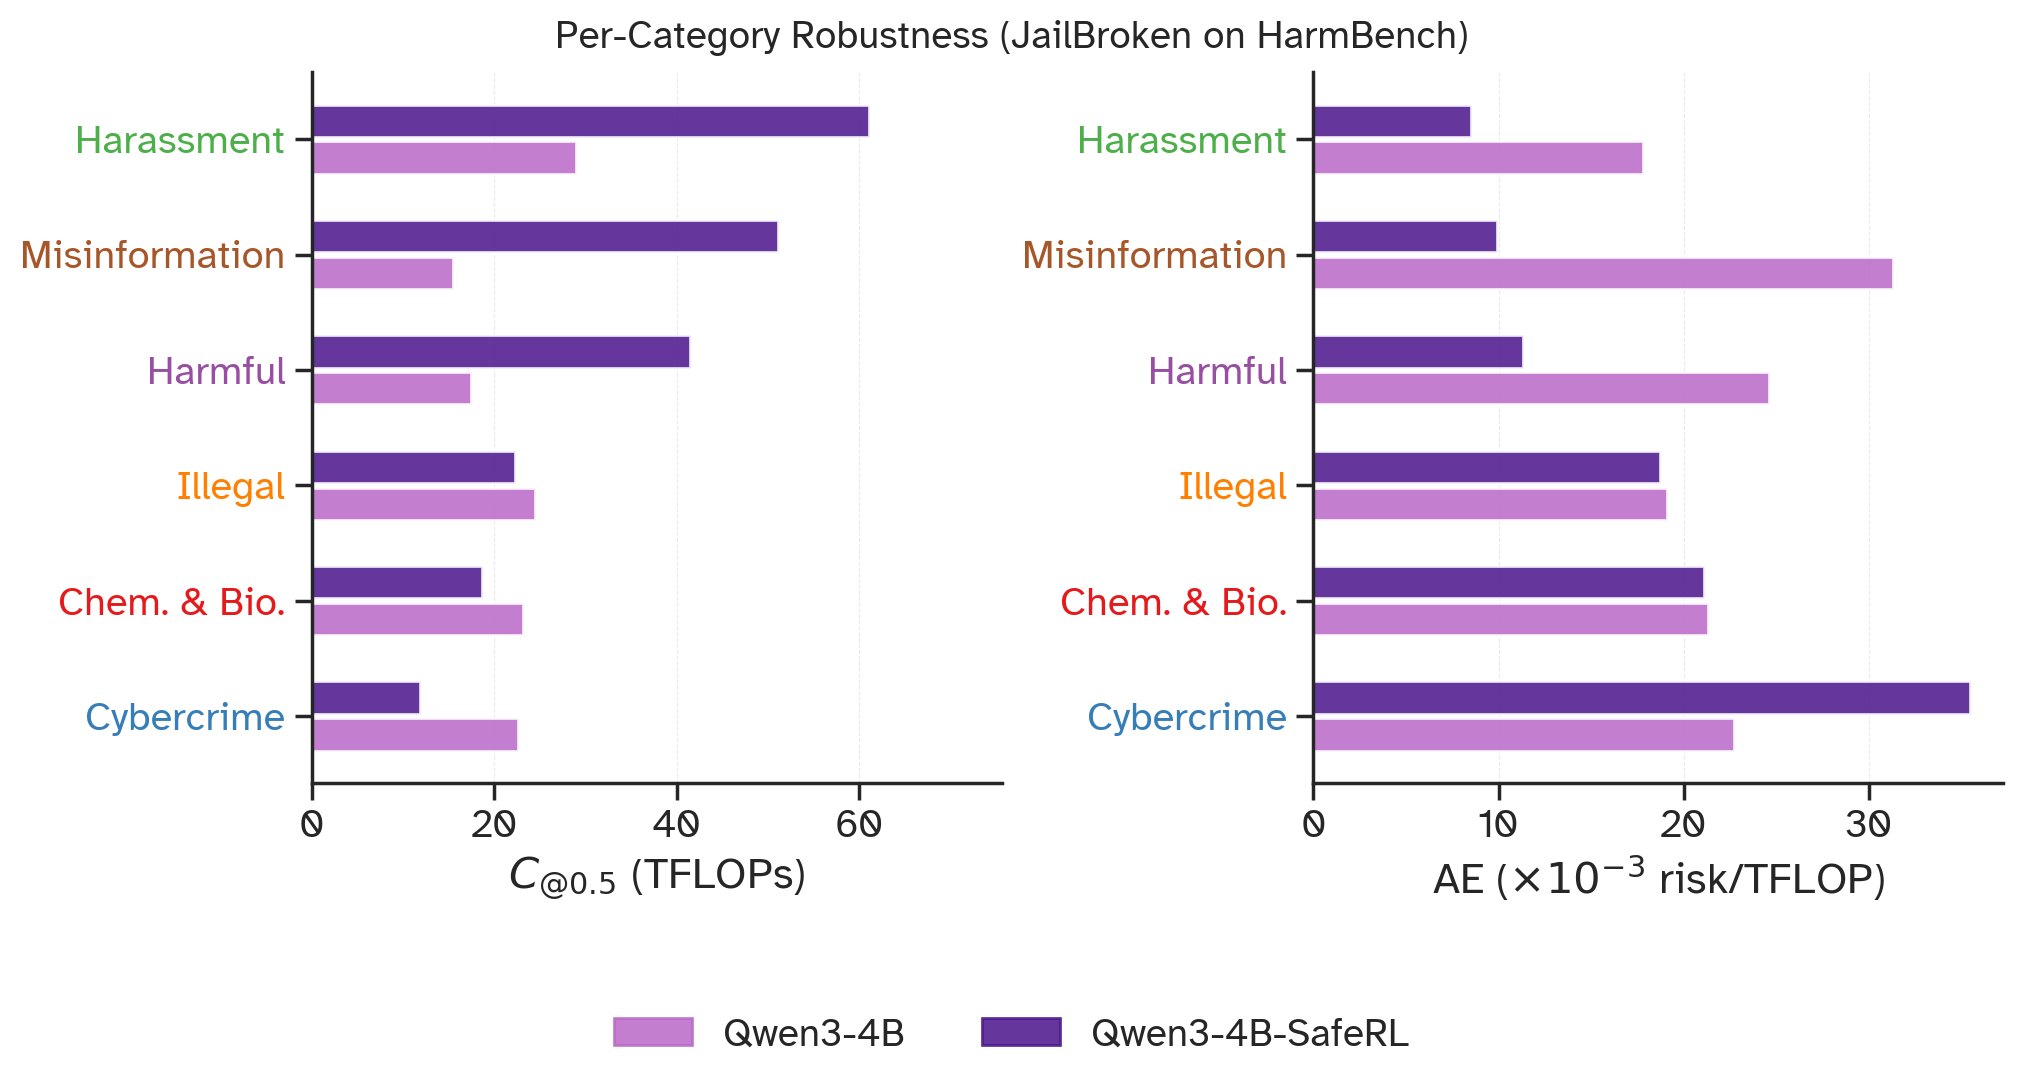

In [52]:
# ── Per-category robustness: C@0.5 and AE grouped bar charts (HarmBench) ─────
# JailBroken attack; sorted by Qwen3-4B-SafeRL: C@0.5 desc, AE asc. No CI.

_CATS_TBL = [
    "Chem. & Bio.", "Cybercrime", "Harassment",
    "Harmful", "Illegal", "Misinformation",
]
_MODS_TBL = ["Qwen3-4B", "Qwen3-4B-SafeRL"]

_C05 = {
    "Qwen3-4B":        [23.1, 22.6, 29.0, 17.4, 24.5, 15.5],
    "Qwen3-4B-SafeRL": [18.6, 11.9, 61.1, 41.4, 22.3, 51.1],
}
_AE = {
    "Qwen3-4B":        [21.3, 22.7, 17.8, 24.6, 19.1, 31.3],
    "Qwen3-4B-SafeRL": [21.1, 35.5,  8.5, 11.3, 18.7,  9.9],
}

_MOD_COLS = {
    "Qwen3-4B":        "#ba68c8",   # lighter purple
    "Qwen3-4B-SafeRL": "#4a148c",   # dark purple
}

_cat_color_map_hb = {c: _CATEGORY_PALETTE[i % len(_CATEGORY_PALETTE)]
                     for i, c in enumerate(sorted(_CATS_TBL))}

_INF_CAP = 72.0
_BH      = 0.28
_GAP     = 0.04
_OFFSETS = [+(_BH + _GAP) / 2, -(_BH + _GAP) / 2]

_rl        = "Qwen3-4B-SafeRL"
_c05_order = sorted(range(len(_CATS_TBL)), key=lambda i: _C05[_rl][i], reverse=True)
_ae_order  = sorted(range(len(_CATS_TBL)), key=lambda i: _AE[_rl][i])

fig_tbl, (ax_c05, ax_ae) = plt.subplots(1, 2, figsize=(10, 4.5), layout="constrained")

for ax, vals_d, sort_order, xlabel, inf_cap in [
    (ax_c05, _C05, _c05_order, r"$C_{@0.5}$ (TFLOPs)",               _INF_CAP),
    (ax_ae,  _AE,  _ae_order,  r"AE ($\times10^{-3}$ risk/TFLOP)", None),
]:
    sorted_cats = [_CATS_TBL[i] for i in sort_order]
    for mi, model in enumerate(_MODS_TBL):
        color = _MOD_COLS[model]
        for rank, orig_idx in enumerate(sort_order):
            val = vals_d[model][orig_idx]
            y   = rank + _OFFSETS[mi]
            if val is None:
                ax.barh(y, inf_cap, height=_BH, color=color, alpha=0.30,
                        hatch="///", edgecolor=color, linewidth=0.6, zorder=2)
                ax.text(inf_cap * 0.97, y, r"$\infty$",
                        va="center", ha="right", fontsize=11,
                        color=color, fontweight="bold")
            else:
                ax.barh(y, val, height=_BH, color=color, alpha=0.85, zorder=2)

    ax.set_yticks(range(len(_CATS_TBL)))
    ax.set_yticklabels(sorted_cats)
    for tick, cat in zip(ax.get_yticklabels(), sorted_cats):
        tick.set_color(_cat_color_map_hb[cat])
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.4)
    sns.despine(ax=ax)
    if inf_cap:
        ax.set_xlim(0, inf_cap * 1.05)

_leg_tbl = fig_tbl.legend(
    handles=[mpatches.Patch(color=_MOD_COLS[m], alpha=0.85, label=m) for m in _MODS_TBL],
    loc="upper center", bbox_to_anchor=(0.5, -0.08),
    ncols=2, frameon=False, fontsize=14,
)
_sup_tbl = fig_tbl.suptitle(
    "Per-Category Robustness (JailBroken on HarmBench)",
    fontsize=14, fontweight="bold",
)
_TBL_OUT = Path(
    "/Users/malikehehghaghi/Downloads/prisk-pressure/"
    "results/plots/cost/harmbench/ablations"
)
_save(fig_tbl, _TBL_OUT / f"per_category_robustness_jailbroken.{FMT}",
      extra_artists=(_sup_tbl, _leg_tbl))
plt.show()


## Per-Category Robustness -- C@0.5 and AE (JailbreakBench, JailBroken)
Same layout as the HarmBench per-category chart.
Left: $C_{@0.5}$ (TFLOPs; higher = more robust; hatched = budget not reached).
Right: AE ($\\times10^{-3}$ risk/TFLOP; lower = more robust).
10 JailbreakBench categories; 3 model representatives.

  Saved: /Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/cost/jailbreakbench/ablations/per_category_robustness_jailbroken.png


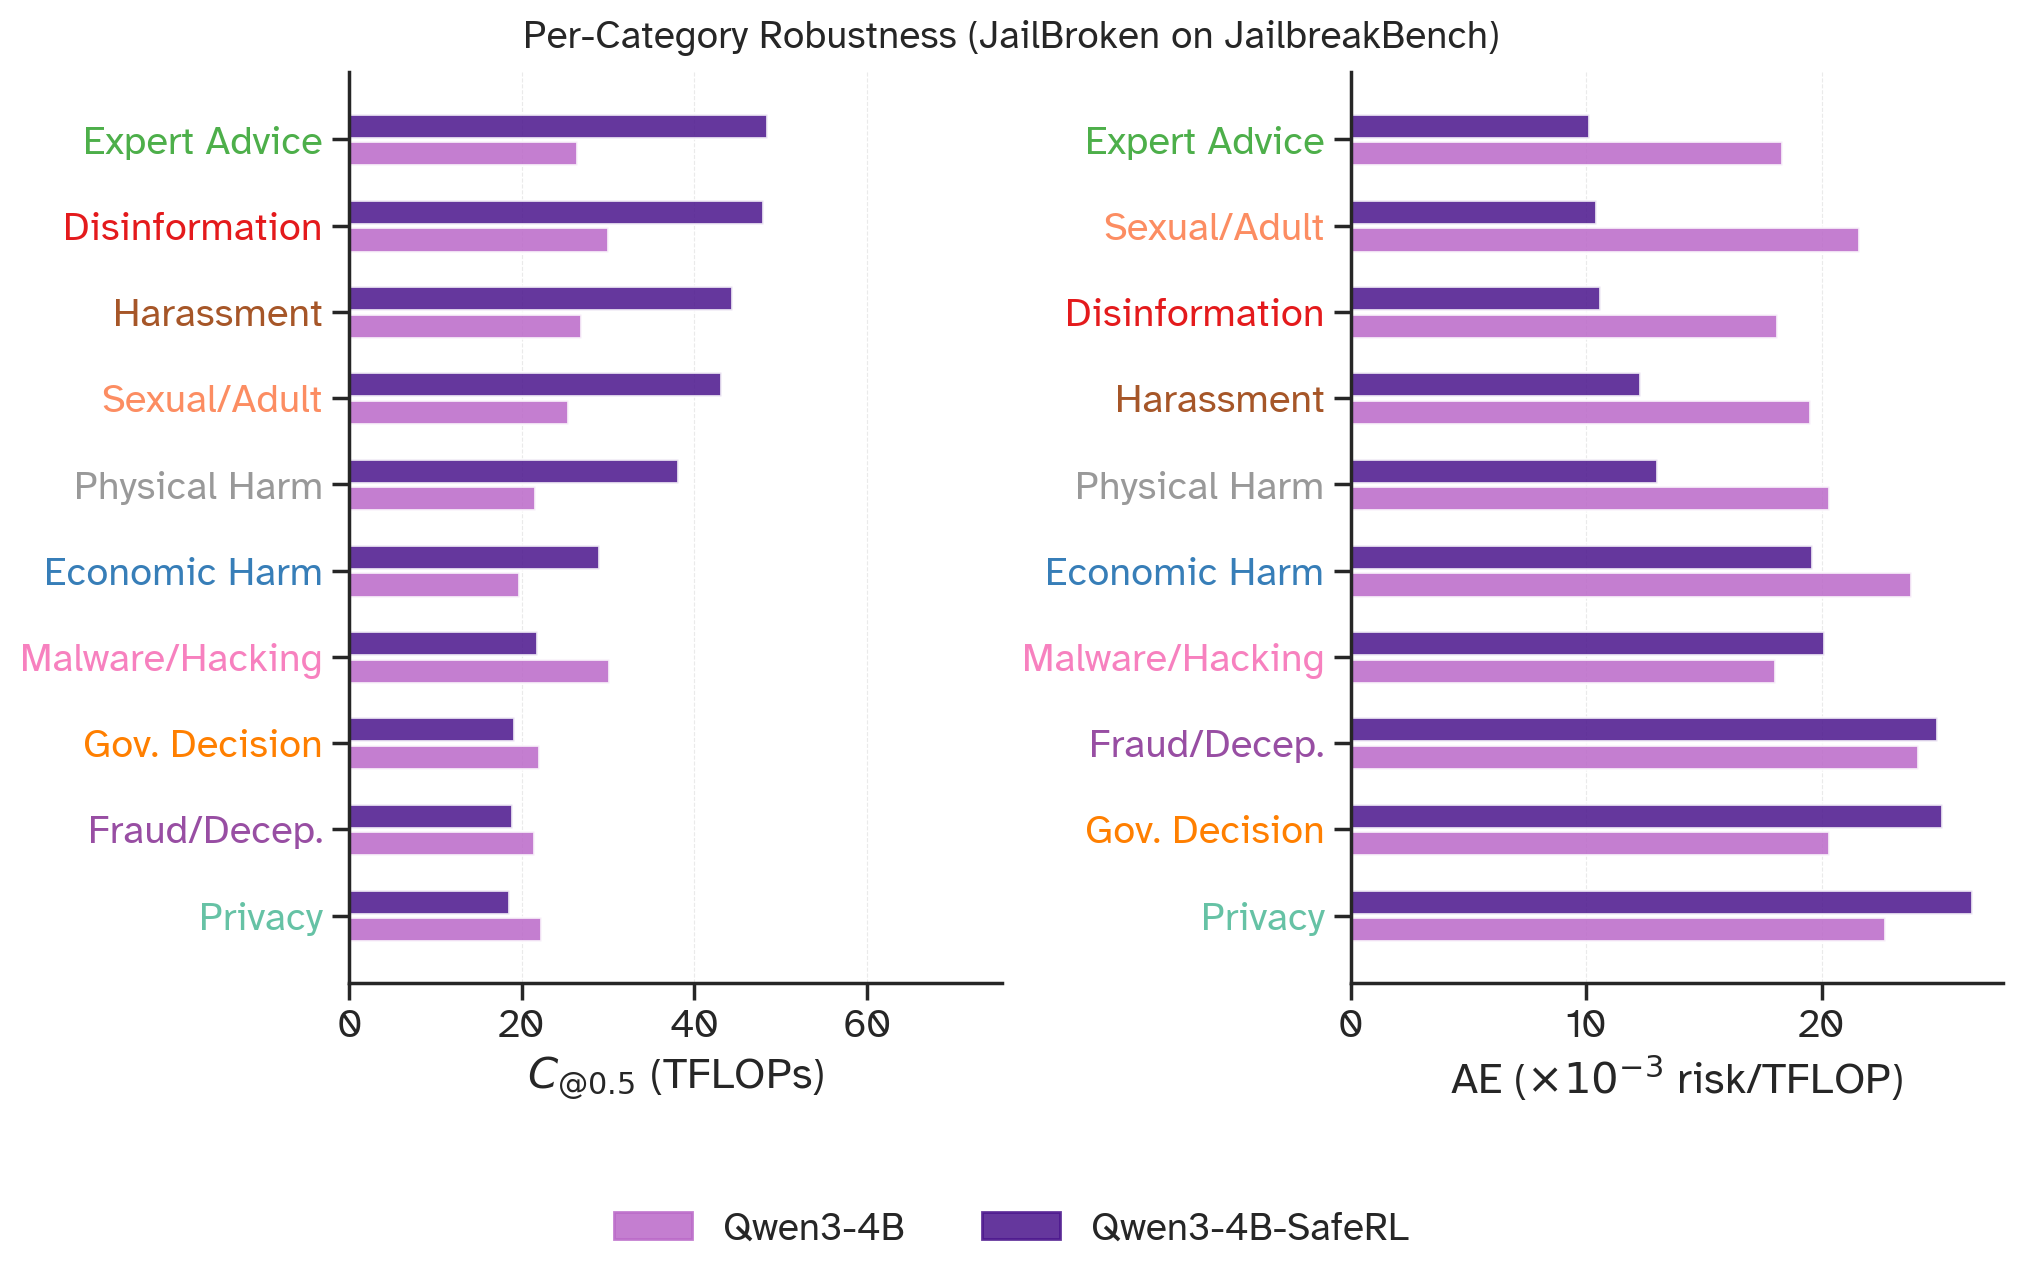

In [53]:
# ── Per-category robustness: C@0.5 and AE (JailbreakBench, JailBroken) ────────
# Sorted by Qwen3-4B-SafeRL: C@0.5 desc, AE asc. No CI.

_CATS_JBB = [
    "Disinformation", "Economic Harm", "Expert Advice", "Fraud/Decep.",
    "Gov. Decision",  "Harassment",    "Malware/Hacking",
    "Physical Harm",  "Privacy",       "Sexual/Adult",
]
_MODS_JBB = ["Qwen3-4B", "Qwen3-4B-SafeRL"]

_C05_JBB = {
    "Qwen3-4B":        [30.0, 19.7, 26.4, 21.4, 22.0, 26.8, 30.1, 21.5, 22.2, 25.4],
    "Qwen3-4B-SafeRL": [47.9, 28.9, 48.4, 18.9, 19.1, 44.4, 21.7, 38.1, 18.5, 43.1],
}
_AE_JBB = {
    "Qwen3-4B":        [18.1, 23.8, 18.3, 24.1, 20.3, 19.5, 18.0, 20.3, 22.7, 21.6],
    "Qwen3-4B-SafeRL": [10.6, 19.6, 10.1, 24.9, 25.1, 12.3, 20.1, 13.0, 26.4, 10.4],
}

_MOD_COLS_JBB = {
    "Qwen3-4B":        "#ba68c8",
    "Qwen3-4B-SafeRL": "#4a148c",
}

_cat_color_map_jbb = {c: _CATEGORY_PALETTE[i % len(_CATEGORY_PALETTE)]
                      for i, c in enumerate(sorted(_CATS_JBB))}

_INF_CAP_JBB = 72.0
_BH_JBB      = 0.28
_GAP_JBB     = 0.04
_OFFSETS_JBB = [+(_BH_JBB + _GAP_JBB) / 2, -(_BH_JBB + _GAP_JBB) / 2]

_rl_jbb        = "Qwen3-4B-SafeRL"
_c05_order_jbb = sorted(range(len(_CATS_JBB)), key=lambda i: _C05_JBB[_rl_jbb][i], reverse=True)
_ae_order_jbb  = sorted(range(len(_CATS_JBB)), key=lambda i: _AE_JBB[_rl_jbb][i])

fig_jbb, (ax_c05_jbb, ax_ae_jbb) = plt.subplots(1, 2, figsize=(10, 5.5), layout="constrained")

for ax, vals_d, sort_order, xlabel, inf_cap in [
    (ax_c05_jbb, _C05_JBB, _c05_order_jbb, r"$C_{@0.5}$ (TFLOPs)",               _INF_CAP_JBB),
    (ax_ae_jbb,  _AE_JBB,  _ae_order_jbb,  r"AE ($\times10^{-3}$ risk/TFLOP)", None),
]:
    sorted_cats = [_CATS_JBB[i] for i in sort_order]
    for mi, model in enumerate(_MODS_JBB):
        color = _MOD_COLS_JBB[model]
        for rank, orig_idx in enumerate(sort_order):
            val = vals_d[model][orig_idx]
            y   = rank + _OFFSETS_JBB[mi]
            ax.barh(y, val, height=_BH_JBB, color=color, alpha=0.85, zorder=2)

    ax.set_yticks(range(len(_CATS_JBB)))
    ax.set_yticklabels(sorted_cats)
    for tick, cat in zip(ax.get_yticklabels(), sorted_cats):
        tick.set_color(_cat_color_map_jbb[cat])
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.4)
    sns.despine(ax=ax)
    if inf_cap:
        ax.set_xlim(0, inf_cap * 1.05)

_leg_jbb = fig_jbb.legend(
    handles=[mpatches.Patch(color=_MOD_COLS_JBB[m], alpha=0.85, label=m) for m in _MODS_JBB],
    loc="upper center", bbox_to_anchor=(0.5, -0.06),
    ncols=2, frameon=False, fontsize=14,
)
_sup_jbb = fig_jbb.suptitle(
    "Per-Category Robustness (JailBroken on JailbreakBench)",
    fontsize=14, fontweight="bold",
)
_JBB_OUT = Path(
    "/Users/malikehehghaghi/Downloads/prisk-pressure/"
    "results/plots/cost/jailbreakbench/ablations"
)
_save(fig_jbb, _JBB_OUT / f"per_category_robustness_jailbroken.{FMT}",
      extra_artists=(_sup_jbb, _leg_jbb))
plt.show()


## Qwen3-4B vs Qwen3-4B-SafeRL — Risk Curves (HarmBench)
Per-attack comparison using the same purple shades as the per-category figures.

Qwen3 HB: 399 rows — 2 model(s), 3 attack(s)
  Saved: /Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/cost/harmbench/ablations/qwen3_saferl/cost_comparison_all.png


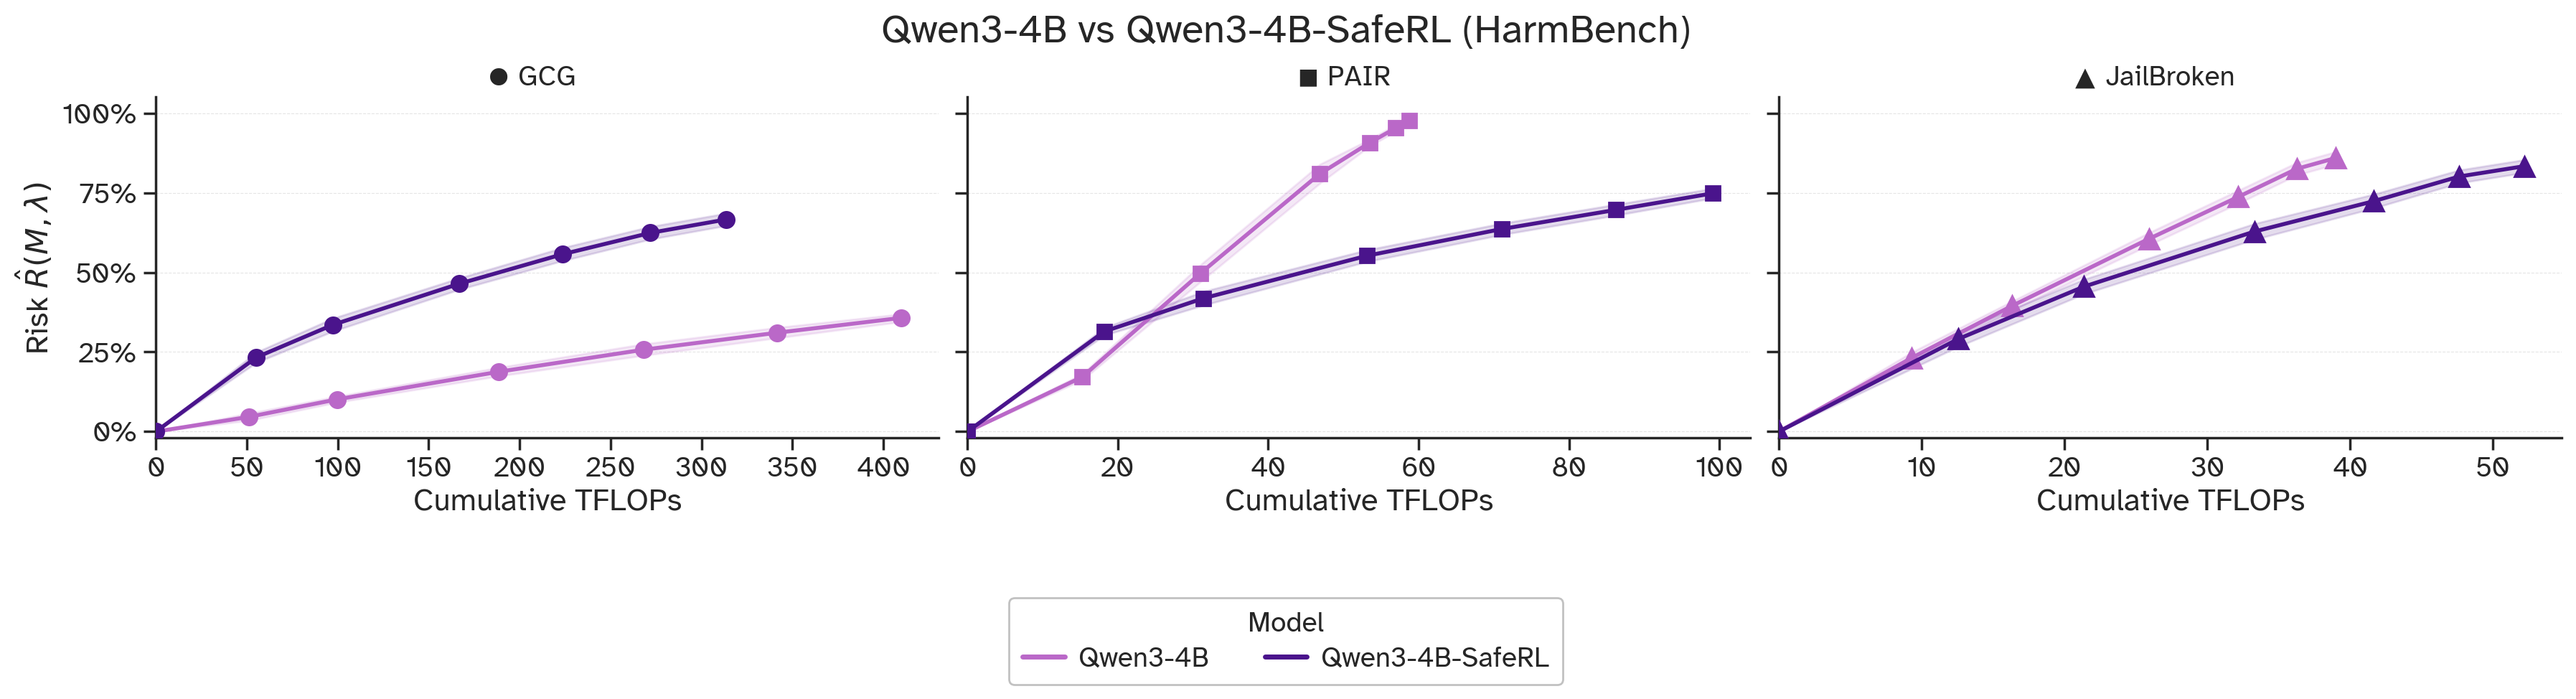

In [54]:
# ── Qwen3-4B vs Qwen3-4B-SafeRL: risk curves (HarmBench) ─────────────────────

_Q3_HB_CSVS = [
    Path("/Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/multitrial_experiments/pressure_sensitivity/harmbench/qwen3-4b/cost/cost_metrics.csv"),
    Path("/Users/malikehehghaghi/Downloads/Final-Plots/results/plots/multitrial_experiments/pressure_sensitivity/harmbench/qwen3-4b-saferl/cost/cost_metrics.csv"),
]
_Q3_HB_OUT   = Path("/Users/malikehehghaghi/Downloads/prisk-pressure/results/plots/cost/harmbench/ablations/qwen3_saferl")
_Q3_HB_TITLE = "HarmBench — Qwen3-4B vs Qwen3-4B-SafeRL"

_Q3_COLORS = {"qwen3-4b": "#ba68c8", "qwen3-4b-saferl": "#4a148c"}
_Q3_ORDER  = {"qwen3-4b": 0, "qwen3-4b-saferl": 1}

def _q3_color_map(models):
    return {m: _Q3_COLORS.get(m, "#888888") for m in models}

from plot_cost_curves import MODEL_DISPLAY
MODEL_DISPLAY["qwen3-4b"] = "Qwen3-4B"

_df_q3_hb_raw = load_cost_csv(_Q3_HB_CSVS, skip_missing=SKIP_MISSING)
_df_q3_hb_raw = _df_q3_hb_raw[_df_q3_hb_raw["attack_id"] != "jailbroken-v1"]
_df_q3_hb_agg = aggregate_seeds(_df_q3_hb_raw)
_n_q3_hb = _df_q3_hb_raw["model_id"].apply(_base).nunique()
print(f"Qwen3 HB: {len(_df_q3_hb_raw):,} rows — {_n_q3_hb} model(s), "
      f"{_df_q3_hb_raw['attack_id'].nunique()} attack(s)")

_AE_LABELS_orig, _AE_LABELS = _AE_LABELS, {}
OUTPUT_DIR_orig, OUTPUT_DIR   = OUTPUT_DIR, _Q3_HB_OUT

if _n_q3_hb > 0:
    show_comparison(_df_q3_hb_agg, suptitle=_Q3_HB_TITLE,
                    color_map_fn=_q3_color_map, model_order=_Q3_ORDER,
                    annotate_fn=lambda *a, **k: None)

_AE_LABELS, OUTPUT_DIR = _AE_LABELS_orig, OUTPUT_DIR_orig
